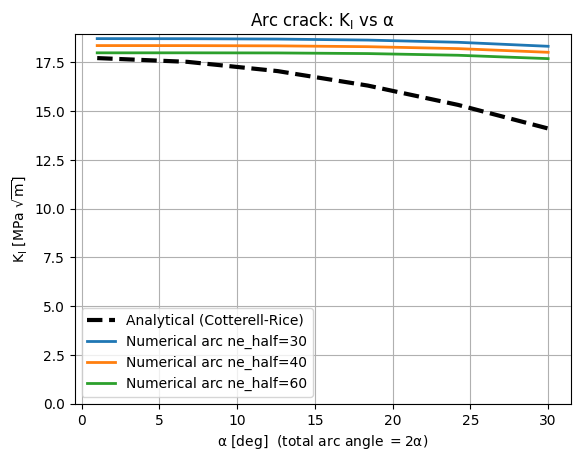

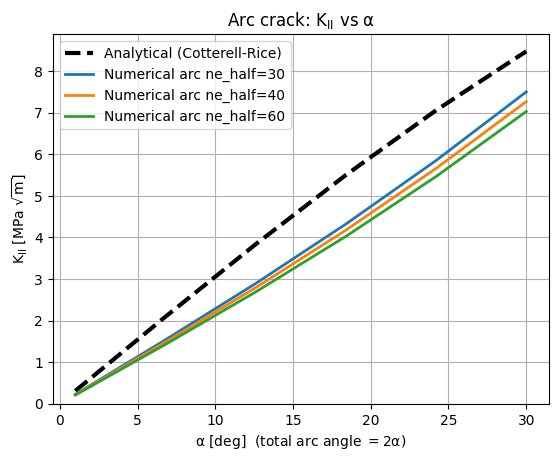

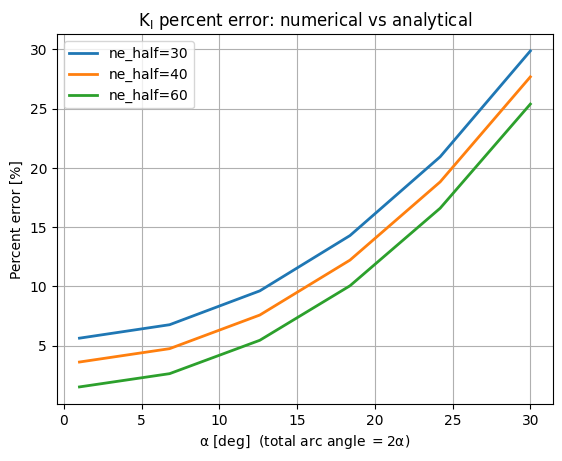

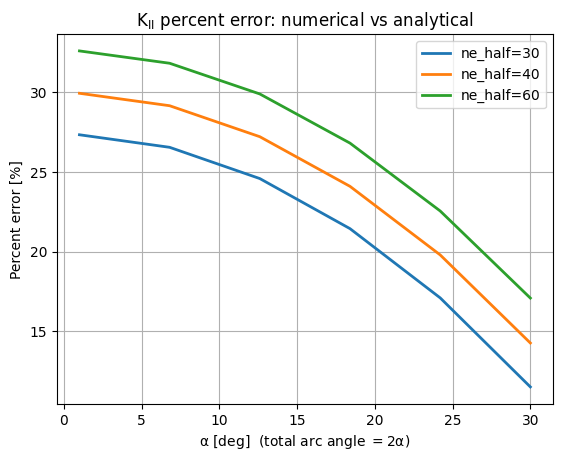

In [3]:
# ============================================================
# Cotterell?Rice (IJF 1980) validation for circular arc crack
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *
out_dir = Path(repo_root) / "output" / "Arc_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm     # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(1.0, 30.0, 6)
alpha = np.deg2rad(alpha_deg)

ne_half_values = [30, 40, 60]
scale = 1e-6

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

# -------------------------
# Arc geometry (TRUE circle center)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],
    ], float)

    E_conn = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=E_conn,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

# -------------------------
# Solver wrapper
# -------------------------
def solve_K_arc(net, ne_half, al):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    a_arc = float(extra["a_edge"])

    mu = E / (2.0 * (1.0 + nu))
    kappa = 3.0 - 4.0 * nu

    KI, KII, _ = sif_from_cod_fit(
        x=x,
        COD=COD,
        CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.2,
        min_pts=10,
        n_fit=400,
        two_term=False,
    )

    KI_rn, KII_rn = rotate_sifs(float(KI), float(KII), -2.0 * al)
    return KI_rn, -KII_rn


# -------------------------
# Run sweep
# -------------------------
KI_ana, KII_ana = [], []
for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al
    KIa, KIIa = cotterell_rice_K(al, a_arc, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

KI_ana = np.asarray(KI_ana, float)
KII_ana = np.asarray(KII_ana, float)

num_by_ne = {}
for ne_half in ne_half_values:
    KI_num, KII_num = [], []
    for al in alpha:
        net = arc_network(al)
        ki, kii = solve_K_arc(net, ne_half, al)
        KI_num.append(ki)
        KII_num.append(kii)

    num_by_ne[ne_half] = {
        "KI": np.asarray(KI_num, float),
        "KII": np.asarray(KII_num, float),
    }

# -------------------------
# Plots: KI and KII overlays
# -------------------------
colors = {30: "tab:blue", 40: "tab:orange", 60: "tab:green"}

fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana * scale, "k--", lw=3, label="Analytical (Cotterell-Rice)")
for ne_half in ne_half_values:
    ax1.plot(
        alpha_deg,
        num_by_ne[ne_half]["KI"] * scale,
        lw=2,
        color=colors[ne_half],
        label=f"Numerical arc ne_half={ne_half}",
    )
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title(r"Arc crack: $K_I$ vs $\alpha$")
ax1.grid(True)
ax1.legend()
ax1.set_ylim(bottom=0)
fig1.savefig(out_dir / "KI_vs_alpha_ne30_40_60.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana * scale, "k--", lw=3, label="Analytical (Cotterell-Rice)")
for ne_half in ne_half_values:
    ax2.plot(
        alpha_deg,
        num_by_ne[ne_half]["KII"] * scale,
        lw=2,
        color=colors[ne_half],
        label=f"Numerical arc ne_half={ne_half}",
    )
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title(r"Arc crack: $K_{II}$ vs $\alpha$")
ax2.grid(True)
ax2.legend()
ax2.set_ylim(bottom=0)
fig2.savefig(out_dir / "KII_vs_alpha_ne30_40_60.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# Plots: percent error overlays
# -------------------------
def percent_error(num, ana, eps=1e-14):
    return 100.0 * np.abs(num - ana) / np.maximum(np.abs(ana), eps)

fig3, ax3 = plt.subplots()
for ne_half in ne_half_values:
    err_ki = percent_error(num_by_ne[ne_half]["KI"], KI_ana)
    ax3.plot(alpha_deg, err_ki, lw=2, color=colors[ne_half], label=f"ne_half={ne_half}")
ax3.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax3.set_ylabel(r"Percent error [%]")
ax3.set_title(r"$K_I$ percent error: numerical vs analytical")
ax3.grid(True)
ax3.legend()
fig3.savefig(out_dir / "KI_percent_error_ne30_40_60.png", dpi=300, bbox_inches="tight")
plt.show()

fig4, ax4 = plt.subplots()
for ne_half in ne_half_values:
    err_kii = percent_error(num_by_ne[ne_half]["KII"], KII_ana)
    ax4.plot(alpha_deg, err_kii, lw=2, color=colors[ne_half], label=f"ne_half={ne_half}")
ax4.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax4.set_ylabel(r"Percent error [%]")
ax4.set_title(r"$K_{II}$ percent error: numerical vs analytical")
ax4.grid(True)
ax4.legend()
fig4.savefig(out_dir / "KII_percent_error_ne30_40_60.png", dpi=300, bbox_inches="tight")
plt.show()



findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

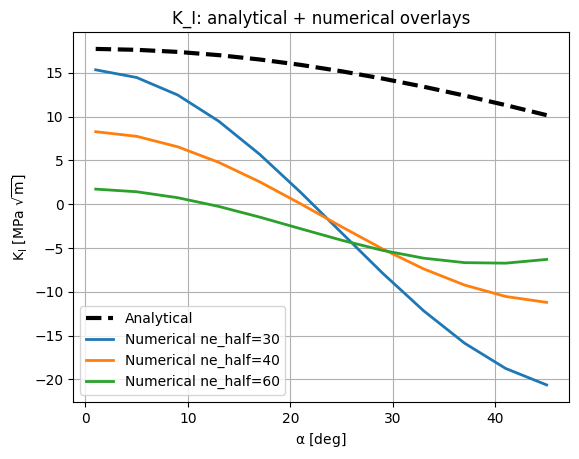

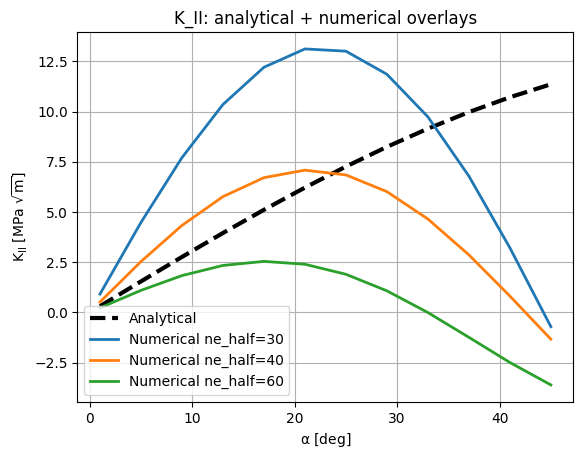

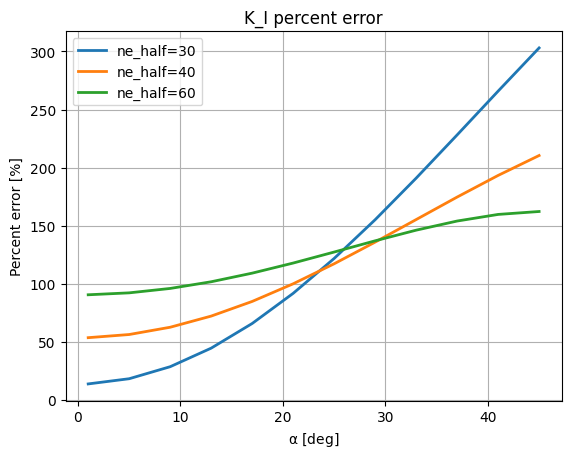

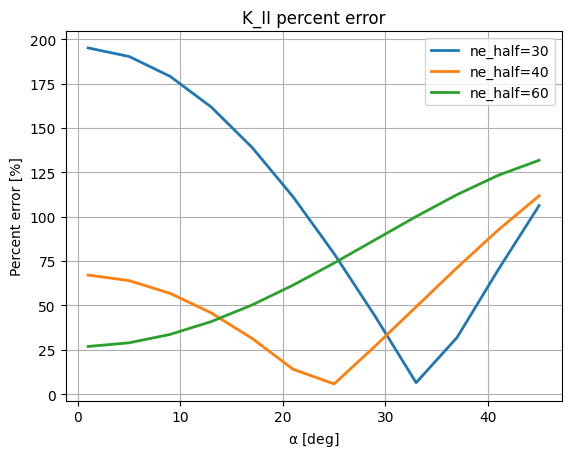

In [1]:
# ============================================================
# Cotterell-Rice validation for circular arc crack using a POLYLINE approximation
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *
out_dir = Path(repo_root) / "output" / "ArcPolyline_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

mm = 1e-3
a_chord = 10.0 * mm
E = 200e9
nu = 0.30
plane = "stress"

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

alpha_deg = np.linspace(1.0, 45.0, 12)
alpha = np.deg2rad(alpha_deg)

ne_half_values = [30, 40, 60]
nseg_test = 25
scale = 1e-6

min_segs = 6
fit_frac = 0.30
rmax_frac = 0.30
two_term = True

base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

from fracture_utils.Uprocessor import SIF_cod as sifcod

def solve_arc_polyline(al, *, ne_half, nseg, fit_frac, min_segs, rmax_frac, two_term):
    R = a_chord / np.sin(al)
    a_arc = R * al
    net, V = polyline_arc_network(al, a_chord, nseg=nseg)
    edge_tip = int(nseg - 1)

    KI, KII, KI_CR, KII_CR, meta = sifcod.solve_K_polyline(
        net=net,
        V=V,
        ne_half=int(ne_half),
        edge_index_use=edge_tip,
        a_fit_global=float(a_arc),
        E=E, nu=nu, plane=plane,
        sig_xx=sig_xx, sig_yy=sig_yy, sig_xy=sig_xy,
        base_knobs=base_knobs,
        fit_frac=float(fit_frac),
        min_segs=int(min_segs),
        rmin_frac=1e-6,
        rmax_frac=float(rmax_frac),
        min_pts=12,
        two_term=bool(two_term),
        theta_rot_override=float(-2.0 * al),
    )
    return float(a_arc), float(KI_CR), float(KII_CR), meta

KI_ana, KII_ana = [], []
for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al
    KIa, KIIa = cotterell_rice_K(al, a_arc, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

KI_ana = np.asarray(KI_ana, float)
KII_ana = np.asarray(KII_ana, float)

num_by_ne = {}
for ne_half in ne_half_values:
    KI_poly, KII_poly = [], []
    for al in alpha:
        _, KIn, KIIn, _ = solve_arc_polyline(
            al,
            ne_half=ne_half,
            nseg=nseg_test,
            fit_frac=fit_frac,
            min_segs=min_segs,
            rmax_frac=rmax_frac,
            two_term=two_term,
        )
        KI_poly.append(KIn)
        KII_poly.append(KIIn)

    num_by_ne[ne_half] = {
        "KI": np.asarray(KI_poly, float),
        "KII": -np.asarray(KII_poly, float),
    }

colors = {30: "tab:blue", 40: "tab:orange", 60: "tab:green"}

fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana * scale, "k--", lw=3, label="Analytical")
for ne_half in ne_half_values:
    ax1.plot(alpha_deg, num_by_ne[ne_half]["KI"] * scale, lw=2, color=colors[ne_half], label=f"Numerical ne_half={ne_half}")
ax1.set_xlabel(r"$\alpha$ [deg]")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("K_I: analytical + numerical overlays")
ax1.grid(True)
ax1.legend()
fig1.savefig(out_dir / f"K_I_vs_alpha_ne30_40_60_nseg{nseg_test}.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana * scale, "k--", lw=3, label="Analytical")
for ne_half in ne_half_values:
    ax2.plot(alpha_deg, num_by_ne[ne_half]["KII"] * scale, lw=2, color=colors[ne_half], label=f"Numerical ne_half={ne_half}")
ax2.set_xlabel(r"$\alpha$ [deg]")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("K_II: analytical + numerical overlays")
ax2.grid(True)
ax2.legend()
fig2.savefig(out_dir / f"K_II_vs_alpha_ne30_40_60_nseg{nseg_test}.png", dpi=300, bbox_inches="tight")
plt.show()

def percent_error(num, ana, eps=1e-14):
    return 100.0 * np.abs(num - ana) / np.maximum(np.abs(ana), eps)

fig3, ax3 = plt.subplots()
for ne_half in ne_half_values:
    ax3.plot(alpha_deg, percent_error(num_by_ne[ne_half]["KI"], KI_ana), lw=2, color=colors[ne_half], label=f"ne_half={ne_half}")
ax3.set_xlabel(r"$\alpha$ [deg]")
ax3.set_ylabel("Percent error [%]")
ax3.set_title("K_I percent error")
ax3.grid(True)
ax3.legend()
fig3.savefig(out_dir / f"K_I_percent_error_ne30_40_60_nseg{nseg_test}.png", dpi=300, bbox_inches="tight")
plt.show()

fig4, ax4 = plt.subplots()
for ne_half in ne_half_values:
    ax4.plot(alpha_deg, percent_error(num_by_ne[ne_half]["KII"], KII_ana), lw=2, color=colors[ne_half], label=f"ne_half={ne_half}")
ax4.set_xlabel(r"$\alpha$ [deg]")
ax4.set_ylabel("Percent error [%]")
ax4.set_title("K_II percent error")
ax4.grid(True)
ax4.legend()
fig4.savefig(out_dir / f"K_II_percent_error_ne30_40_60_nseg{nseg_test}.png", dpi=300, bbox_inches="tight")
plt.show()



Solving for c/l = 1 (l = 1000.000 mm)...
Solving for c/l = 2 (l = 500.000 mm)...
Solving for c/l = 3 (l = 333.333 mm)...
Solving for c/l = 4 (l = 250.000 mm)...
Solving for c/l = 5 (l = 200.000 mm)...
Solving for c/l = 6 (l = 166.667 mm)...
Solving for c/l = 7 (l = 142.857 mm)...
Solving for c/l = 8 (l = 125.000 mm)...
Solving for c/l = 9 (l = 111.111 mm)...
Solving for c/l = 10 (l = 100.000 mm)...
Solving for c/l = 15 (l = 66.667 mm)...
Solving for c/l = 20 (l = 50.000 mm)...
Solving for c/l = 30 (l = 33.333 mm)...
Solving for c/l = 40 (l = 25.000 mm)...
Solving for c/l = 50 (l = 20.000 mm)...
Solving for c/l = 75 (l = 13.333 mm)...
Solving for c/l = 100 (l = 10.000 mm)...
Solving for c/l = 200 (l = 5.000 mm)...


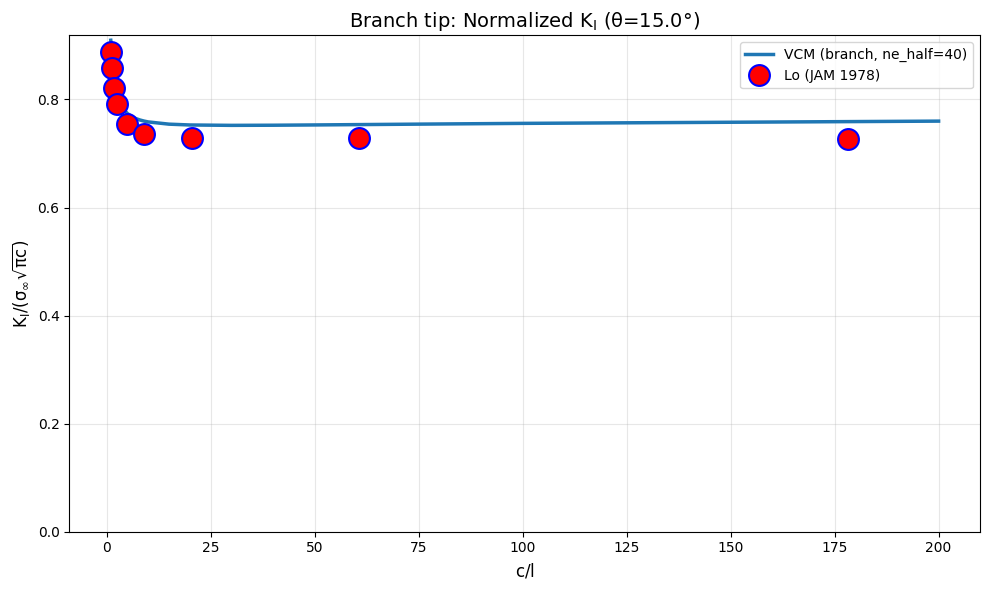

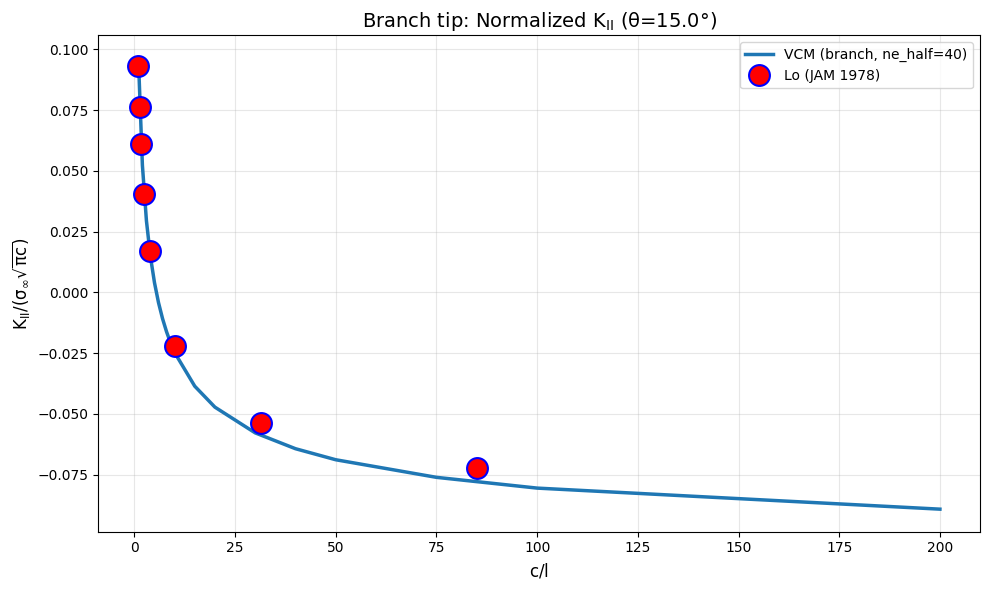

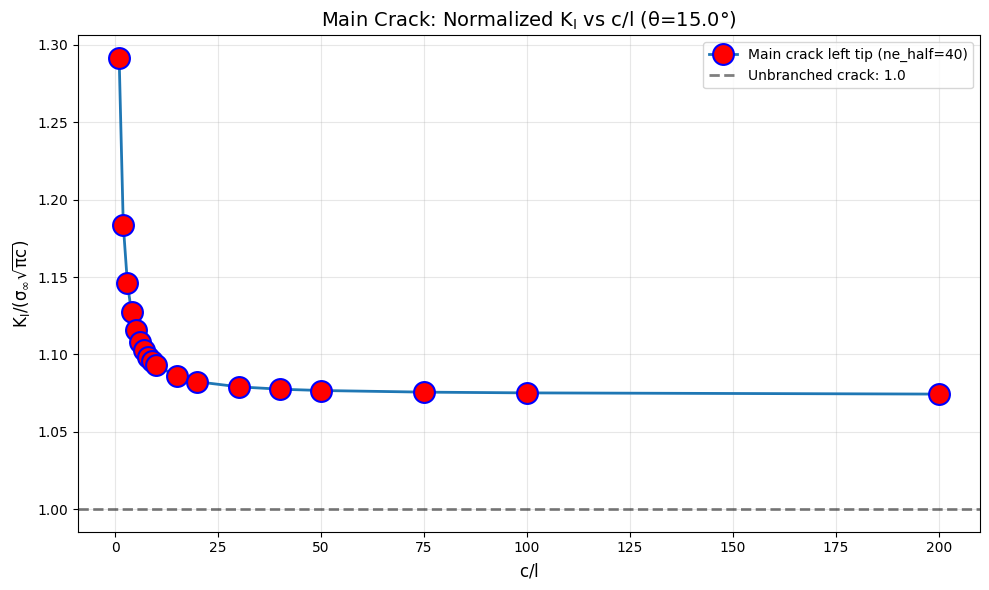

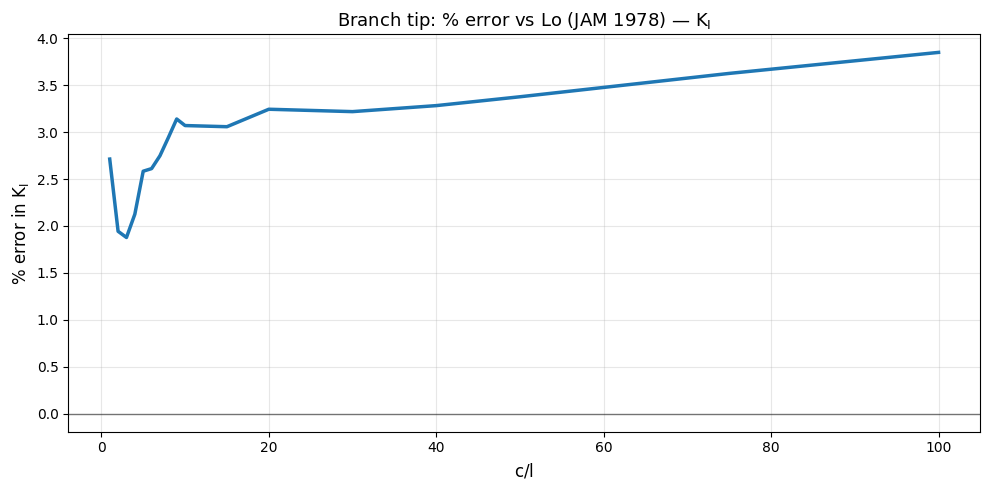

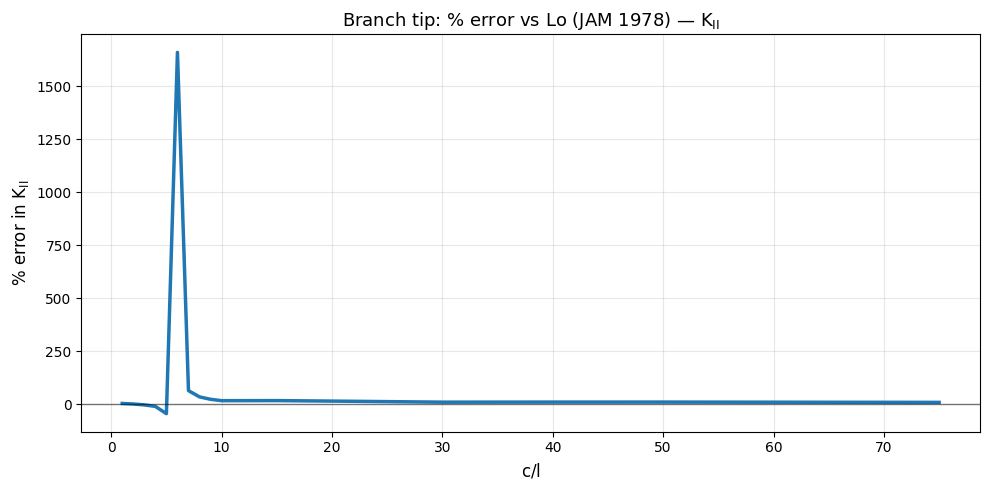


Branched crack validation complete!
Results saved to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_1\output\Branched_Crack_Validation


In [ ]:
## BRANCHED CRACK VALIDATION: Lo J. Applied Mechanics (1978) 45, p797
# ============================================================
# Symmetric Branched Crack (robust Euclidean near-tip fit)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "Branched_Crack_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
c = 1000.0 * mm
# c_over_l = np.linspace(1, 201, 10, dtype=float)
c_over_l = np.array([1,2,3,4,5,6,7,8,9,10,15,20,30,40,50, 75, 100, 200], float)
theta_deg = 15.0
theta = np.deg2rad(theta_deg)

# Material and loading
E = 200e9
nu = 0.30
plane = "strain"
sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

def print_meta(label, ratio, meta, l):
    print(
        f"[{label}] c/l={ratio:g} | "
        f"keys={list(meta.keys())} | "
        f"rr_size={meta.get('rr_size', 'NA')} | "
        f"rmax/l={meta.get('rmax', np.nan)/l if 'rmax' in meta else np.nan:.3f}"
    )

# ----------------------------
# Build branched crack network
# ----------------------------
def build_branched_crack(c, l, theta):
    vertices = np.array([
        [0,  -c,  0.0],
        [1,   c,  0.0],
        [2,   c + l*np.cos(theta),   l*np.sin(theta)],
        [3,   c + l*np.cos(theta),  -l*np.sin(theta)],
    ], dtype=float)

    connectivity = np.array([
        [0, 1],   # e0 main
        [1, 2],   # e1 top branch
        [1, 3],   # e2 bottom branch
    ], dtype=int)

    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=4,
        validate=True
    )
    return net, vertices

# ----------------------------
# Run sweep over c/l ratios
# ----------------------------
KI_top, KII_top = [], []
KI_bot, KII_bot = [], []
KI_main, KII_main = [], []

material = Material(E=E, nu=nu, plane_stress=False)
applied = AppliedStress(sigma_xx=sig_xx, sigma_yy=sig_yy, sigma_xy=sig_xy)

mu = float(material.mu)

# Euclid-fit controls (robust defaults)
rmax_frac_branch = 0.05   # branches can be short => allow a bit wider
rmax_frac_main   = 0.05
min_pts = 4
two_term = True
ne_half = 40

for ratio in c_over_l:
    l = c / ratio

    print(f"Solving for c/l = {ratio:g} (l = {l*1e3:.3f} mm)...")

    net, vertices = build_branched_crack(c, l, theta)

    calc = DCENetworkStaticV4(material, net, applied)
    
    sol = calc.solve(
        ne_half=ne_half,
        crack_mode="half",
        representation="cheb_quad",
        node_distribution="uniform",      # recommended for non-tip segments in this strategy
        nq_col=12,
        nq_stress=16,
        solver_option="parametrized_crack",
        parametrization="polyline",
        junction_model="strict",

        # NEW (tip refinement)
        tip_min_nodes=6,                 # enforce >=6 nodes on each tip segment
        tip_cluster="power",              # "power" (one-sided) or "cheb" (symmetric)
        tip_cluster_power=3.0,            # stronger clustering as p increases (>=2)
        other_min_panels=4,               # baseline per segment
        endpoint_min_nodes=6,        # new
        kink_side_nodes=3,           # new
        refine_junction_endpoints=True,
        refine_kinks=True,
        )
    res = DCEResultsNetworkV4(calc, sol)

    # tip coordinates (global)
    p_top  = vertices[2, 1:3]
    p_bot  = vertices[3, 1:3]
    p_left = vertices[0, 1:3]

    # --- Top branch tip (edge 1, tip at v2)
    try:
        KI_t, KII_t, KI_t_CR, KII_t_CR, meta_t = euclid_tip_fit_from_edge(
            res, edge_index=1, tip_xy=p_top,
            a_fit=l, rmax_frac=rmax_frac_branch, min_pts=min_pts, two_term=two_term, theta=theta,
            material=material
        )
        
        KI_top.append(KI_t)
        KII_top.append(KII_t)
    except Exception as e:
        print(f"  Warning: Top branch fit failed: {e}")
        KI_top.append(np.nan); KII_top.append(np.nan)
    
    # --- Bottom branch tip (edge 2, tip at v3)
    try:
        KI_b, KII_b, KI_b_CR, KII_b_CR, meta_b = euclid_tip_fit_from_edge(
            res, edge_index=2, tip_xy=p_bot,
            a_fit=l, rmax_frac=rmax_frac_branch, min_pts=min_pts, two_term=two_term, theta=-theta,
            material=material
        )
        KI_bot.append(KI_b)
        KII_bot.append(KII_b)
    except Exception as e:
        print(f"  Warning: Bottom branch fit failed: {e}")
        KI_bot.append(np.nan); KII_bot.append(np.nan)

    # --- Main crack left tip (edge 0, tip at v0)
    try:
        KI_m, KII_m, KI_m_CR, KII_m_CR, meta_m = euclid_tip_fit_from_edge(
            res, edge_index=0, tip_xy=p_left,
            a_fit=c,
            rmax_frac=rmax_frac_main, min_pts=min_pts, two_term=two_term, theta=0.0,
            material=material
        )
        KI_main.append(KI_m)
        KII_main.append(KII_m)
    except Exception as e:
        print(f"  Warning: Main crack fit failed: {e}")
        KI_main.append(np.nan); KII_main.append(np.nan)
        
# Convert to arrays
KI_top = np.array(KI_top);   KII_top = np.array(KII_top)
KI_bot = np.array(KI_bot);   KII_bot = np.array(KII_bot)
KI_main = np.array(KI_main); KII_main = np.array(KII_main)

# Normalize by reference SIF
K_ref = sig_yy * np.sqrt(np.pi * c)
KI_branch_norm = KI_top / K_ref
KII_branch_norm = KII_top / K_ref
KI_main_norm = KI_main / K_ref
KII_main_norm = KII_main / K_ref

# -------------------------
# Lo (JAM 1978) digitized data (branch SIFs)
# -------------------------
lo_KI = np.array([
    [0.977157764, 0.888603531],
    [1.22156035 , 0.858908507],
    [1.754476973, 0.820385233],
    [2.494862119, 0.792295345],
    [4.855432594, 0.755377207],
    [8.929324781, 0.736918138],
    [20.46800156, 0.728892456],
    [60.6877622 , 0.728089888],
    [178.2899264, 0.727287319],
], float)

lo_KII = np.array([
    [0.995465377, 0.093361835],
    [1.306903865, 0.076523857],
    [1.683851068, 0.061291159],
    [2.450969943, 0.040453082],
    [3.918340794, 0.017222372],
    [10.20229795, -0.021991258],
    [31.44051859, -0.053922155],
    [84.94829929, -0.07220161],
], float)

lo_cl_KI,  lo_KI_norm  = lo_KI[:,0],  lo_KI[:,1]
lo_cl_KII, lo_KII_norm = lo_KII[:,0], lo_KII[:,1]

def interp_logx(xq, x, y):
    """
    Interpolate y(x) onto query points xq using linear interpolation in log10(x).
    Assumes x > 0 and sorted ascending.
    """
    xq = np.asarray(xq, float)
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)

    m = (xq > 0) & (xq >= x.min()) & (xq <= x.max())
    yq = np.full_like(xq, np.nan, dtype=float)
    yq[m] = np.interp(np.log10(xq[m]), np.log10(x), y)
    return yq

loKI_on_grid  = interp_logx(c_over_l, lo_cl_KI,  lo_KI_norm)
loKII_on_grid = interp_logx(c_over_l, lo_cl_KII, lo_KII_norm)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots(figsize=(10, 6))
# Numerical (solid line, no symbols)
ax1.plot(c_over_l, KI_branch_norm, '-', lw=2.5, label=f'VCM (branch, ne_half={ne_half})')
# Lo overlay: blue circle edge, red fill, no line
ax1.plot(
    lo_cl_KI, lo_KI_norm,
    linestyle='None',
    marker='o', markersize=15,
    markerfacecolor='red',
    markeredgecolor='blue',
    markeredgewidth=1.5,
    label="Lo (JAM 1978)"
)
ax1.set_xlabel(r'$c/l$', fontsize=12)
ax1.set_ylabel(r'$K_I / (\sigma_\infty \sqrt{\pi c})$', fontsize=12)
ax1.set_title(f'Branch tip: Normalized $K_I$ (θ={theta_deg}°)', fontsize=14, weight='bold')
ax1.set_ylim(bottom=0.0)  # <-- start y-axis at 0 for KI
ax1.grid(True, alpha=0.3)
ax1.legend()

plt.tight_layout()
fig1.savefig(out_dir / "branched_KI_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(c_over_l, KII_branch_norm, '-', lw=2.5, label=f'VCM (branch, ne_half={ne_half})')
ax2.plot(
    lo_cl_KII, lo_KII_norm,
    linestyle='None',
    marker='o', markersize=15,
    markerfacecolor='red',
    markeredgecolor='blue',
    markeredgewidth=1.5,
    label="Lo (JAM 1978)"
)
ax2.set_xlabel(r'$c/l$', fontsize=12)
ax2.set_ylabel(r'$K_{II} / (\sigma_\infty \sqrt{\pi c})$', fontsize=12)
ax2.set_title(f'Branch tip: Normalized $K_{{II}}$ (θ={theta_deg}°)', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
fig2.savefig(out_dir / "branched_KII_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()


fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(c_over_l, KI_main_norm, 'o-', lw=2, markersize=15, 
         markerfacecolor='red',markeredgecolor='blue', markeredgewidth=1.5,
         label=f'Main crack left tip (ne_half={ne_half})')
ax3.axhline(1.0, color='k', linestyle='--', lw=2, alpha=0.5, label='Unbranched crack: 1.0')
ax3.set_xlabel(r'$c/l$', fontsize=12)
ax3.set_ylabel(r'$K_I / (\sigma_\infty \sqrt{\pi c})$', fontsize=12)
ax3.set_title(f'Main Crack: Normalized $K_I$ vs $c/l$ (θ={theta_deg}°)', fontsize=14, weight='bold')
ax3.set_xscale('linear'); ax3.grid(True, alpha=0.3); ax3.legend()
plt.tight_layout()
fig3.savefig(out_dir / "main_crack_KI_normalized_lin.png", dpi=150, bbox_inches='tight')
plt.show()

err_KI_pct  = 100.0 * (KI_branch_norm  - loKI_on_grid)  / loKI_on_grid
err_KII_pct = 100.0 * (np.abs(KII_branch_norm) - np.abs(loKII_on_grid)) / np.abs(loKII_on_grid)

# Optional: mask where Lo isn't defined over your c/l range
mKI  = np.isfinite(err_KI_pct)
mKII = np.isfinite(err_KII_pct)

fige4, axe1 = plt.subplots(figsize=(10, 5))
axe1.plot(c_over_l[mKI], err_KI_pct[mKI], '-', lw=2.5)
axe1.axhline(0.0, color='k', lw=1, alpha=0.5)
axe1.set_xlabel(r'$c/l$', fontsize=12)
axe1.set_ylabel(r'$\%$ error in $K_I$', fontsize=12)
axe1.set_title(r'Branch tip: $\%$ error vs Lo (JAM 1978) — $K_I$', fontsize=13, weight='bold')
axe1.grid(True, alpha=0.3)
plt.tight_layout()
fige4.savefig(out_dir / "branched_KI_percent_error_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()

# fige5, axe2 = plt.subplots(figsize=(10, 5))
# axe2.plot(c_over_l[mKII], err_KII_pct[mKII], '-', lw=2.5)
# axe2.axhline(0.0, color='k', lw=1, alpha=0.5)
# axe2.set_xlabel(r'$c/l$', fontsize=12)
# axe2.set_ylabel(r'$\%$ error in $K_{II}$', fontsize=12)
# axe2.set_title(r'Branch tip: $\%$ error vs Lo (JAM 1978) — $K_{II}$', fontsize=13, weight='bold')
# axe2.grid(True, alpha=0.3)
# plt.tight_layout()
# fige5.savefig(out_dir / "branched_KII_percent_error_vs_Lo.png", dpi=150, bbox_inches='tight')
# plt.show()


print("\n" + "="*60)
print("Branched crack validation complete!")
print(f"Results saved to: {out_dir}")
print("="*60)


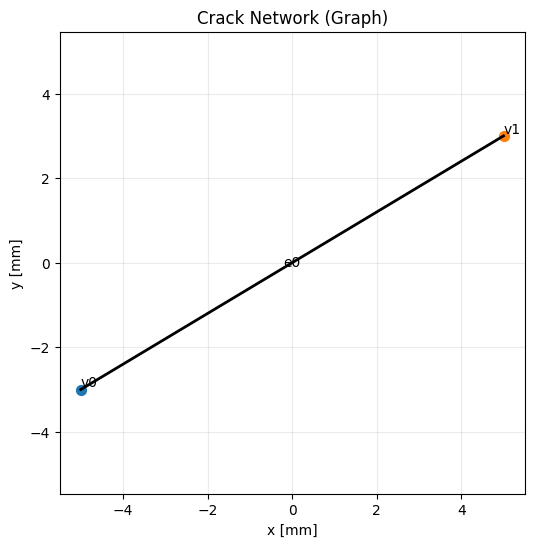

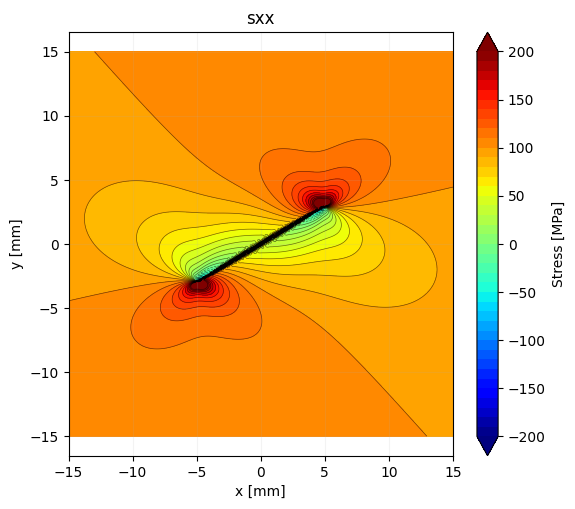

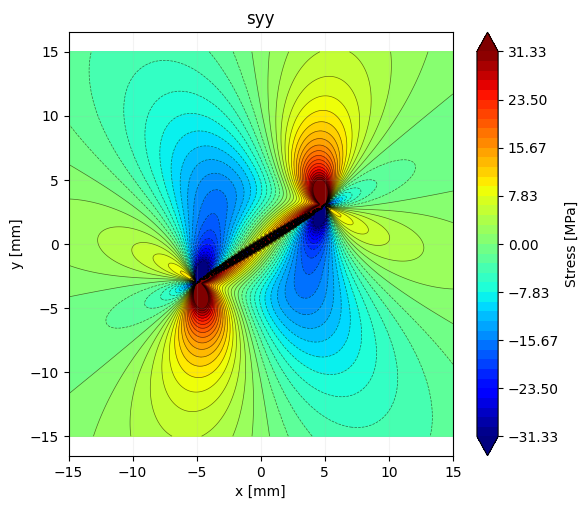

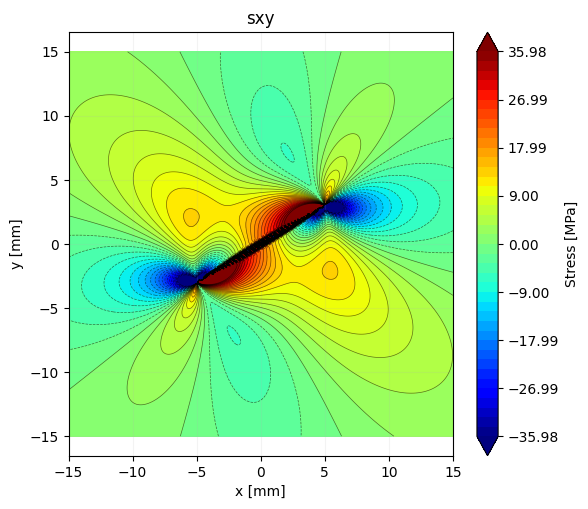

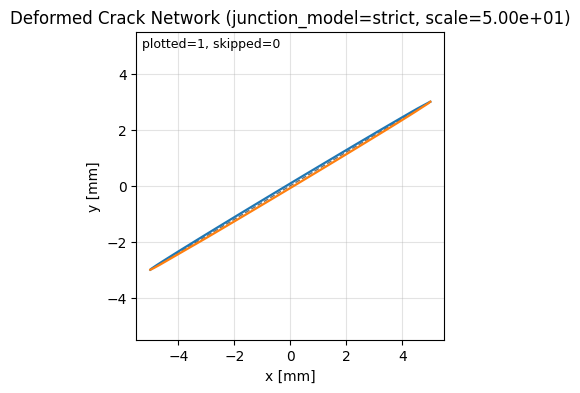

[step_00_initial] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\step_00_initial
[step_01] grown_tips=2
[step_02] grown_tips=2
[step_03] grown_tips=2
[step_04] grown_tips=2
[step_05] grown_tips=2
[step_06] grown_tips=2
[step_07] grown_tips=2
[step_08] grown_tips=2
[step_09] grown_tips=2
[step_10] grown_tips=2
[step_11] grown_tips=2
[step_12] grown_tips=2


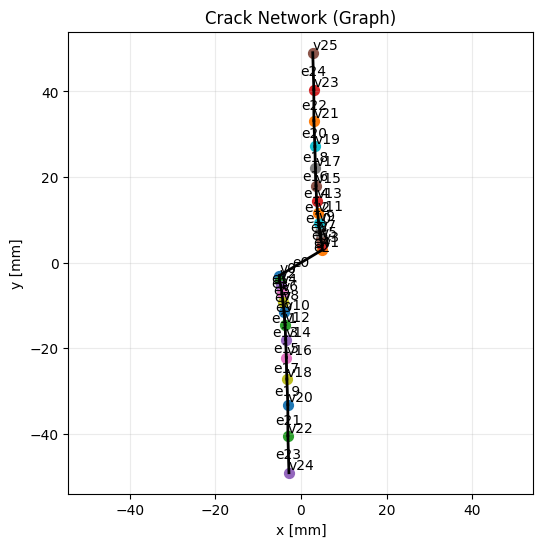

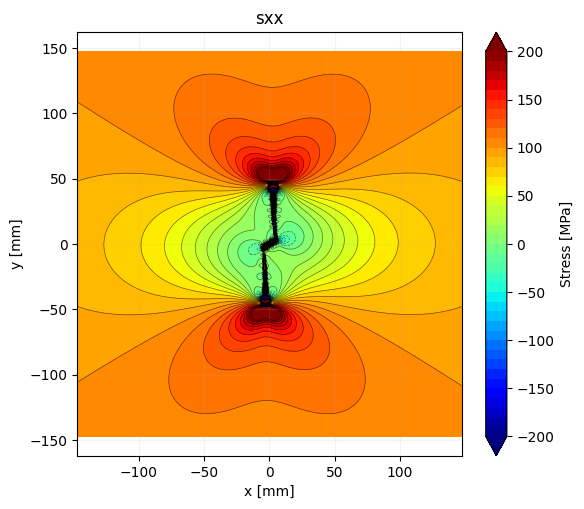

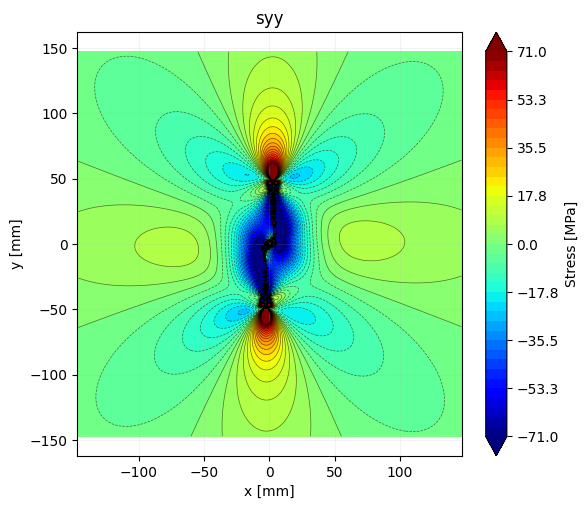

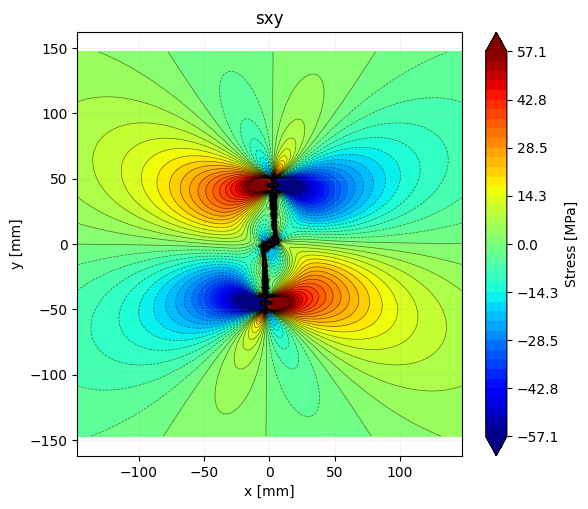

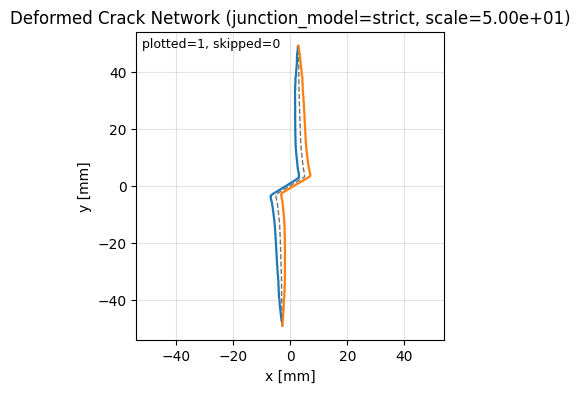

[step_12_final] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\step_12_final
Saved figures under: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation


In [1]:
# ============================================================
# Kinked crack propagation demo
# - single solver_kwargs source of truth
# - plots only initial and final states
# ============================================================

import os, sys
from pathlib import Path

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "KinkedCrackPropagation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build initial network
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  -3.0*mm],
    [1,    5.0*mm,   3.0*mm],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

net0 = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=0.0e6, sigma_xy=0.0)

# ----------------------------
# ONE solver kwargs dict (used everywhere)
# ----------------------------
solver_kwargs = dict(
    ne_half=80,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
    # refinement rules
    refine_kinks=False,
    refine_junction_endpoints=False,
    # how much refinement
    endpoint_min_nodes=4,     # was effectively ~6
    kink_side_nodes=1,         # was 2 in current solver defaults
    # clustering shape
    tip_cluster="power",
    tip_cluster_power=2.5,
    # keep other segments from getting too coarse
    other_min_panels=4,
)

# ----------------------------
# Solve + plot (only when called)
# ----------------------------
def solve_and_plot(network, tag: str):
    step_dir = out_dir / tag
    step_dir.mkdir(parents=True, exist_ok=True)

    calc = DCENetworkStaticV4(material, network, applied)
    sol  = calc.solve(**solver_kwargs)
    res  = DCEResultsNetworkV4(calc, sol)

    plotter = DCEPlotterV4(res, out_dir=step_dir)
    _call(plotter, "plot_network_graph")

    opts = StressPlotOptsV4(
        extent_factor=3,
        n_grid=301,
        add_remote=True,
        mask_cracks=False,
        cmap="jet",
        n_bands=40,
        label_contours=False,
        vmax_factor=2,
    )
    _call(plotter, "plot_stress_components_global", opts=opts, components=("sxx", "syy", "sxy"))

    pl_def = DCEPlotterDeformedV4(res, out_dir=step_dir)
    _call(pl_def, "plot_deformed_network", scale=5e1, trim_core_junction_faces=True)

    plt.show()
    print(f"[{tag}] Saved figures to: {step_dir}")
    return res

# ----------------------------
# Propagation setup
# ----------------------------
cfg = PropagationConfig(f0=0.10, f_fixed=0.1, 
                        step_mode="fixed_step", simultaneous_tip_growth=True)

Kc_demo = 1e6  # Pa*sqrt(m)
tough = ConstantToughness(Kc_demo)

dir_law = MaximumHoopStressLaw()

evaluator = CandidateEvaluator(
    
    material=material,
    applied=applied,
    solver_kwargs=solver_kwargs,   # <-- same dict
    direction_law=dir_law,
    enable_ne_half_escalation=False,  # <-- allow more accurate SIFs during propagation if needed    
)

evaluator.rmax_frac = 0.25
evaluator.min_pts   = 8


prop = CrackPropagator(
    cfg=cfg,
    evaluator=evaluator,
    toughness=tough,
    direction_law=dir_law,
)

# ----------------------------
# Plot INITIAL
# ----------------------------
solve_and_plot(net0, tag="step_00_initial")

# ----------------------------
# Propagate (NO plotting during loop)
# ----------------------------
n_steps = 12
net = net0

for k in range(1, n_steps + 1):
    result = prop.grow_one_increment(net)
    net = result.network_new

    grew = sum(1 for r in result.reports if bool(getattr(r, "grew", False)))
    print(f"[step_{k:02d}] grown_tips={grew}")

    if grew == 0:
        print("No tips exceeded toughness. Stopping.")
        break

# ----------------------------
# Plot FINAL
# ----------------------------
solve_and_plot(net, tag=f"step_{k:02d}_final")
print("Saved figures under:", out_dir)


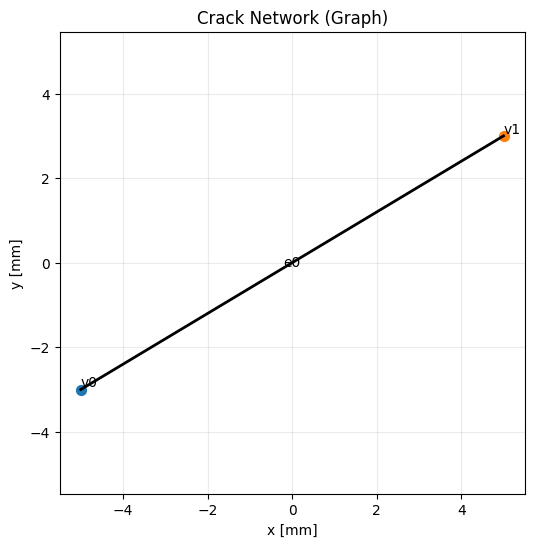

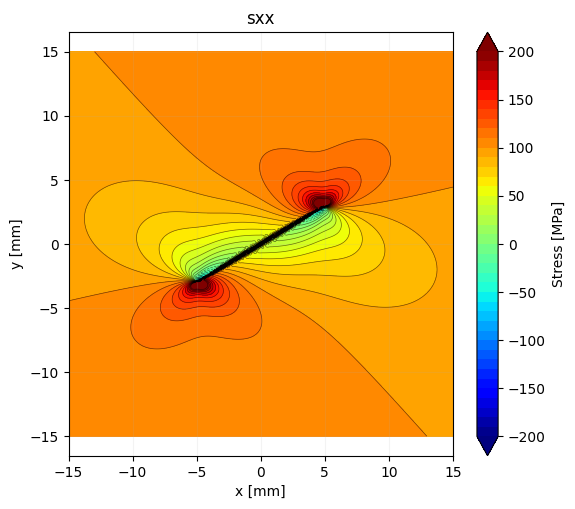

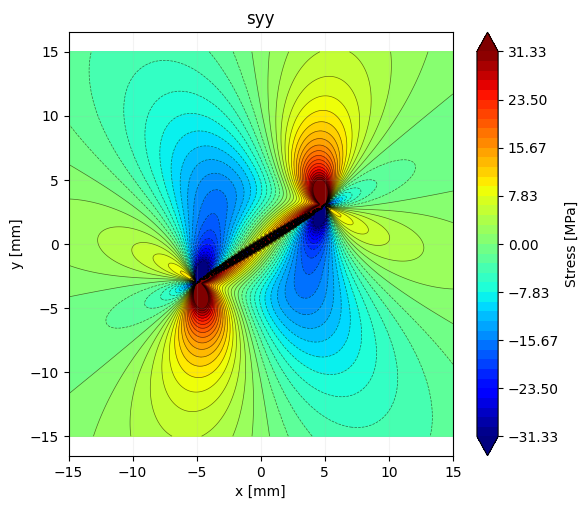

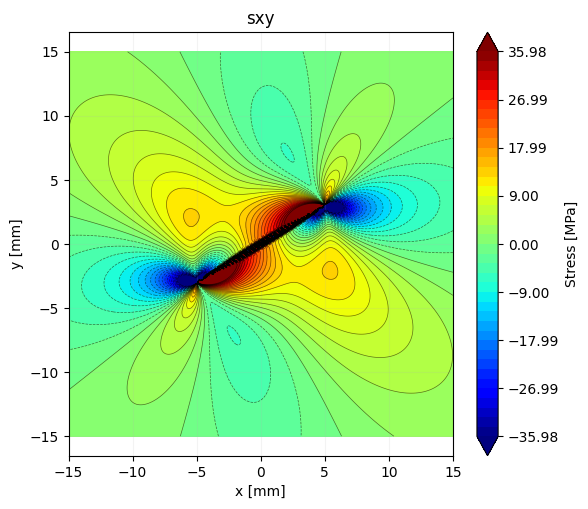

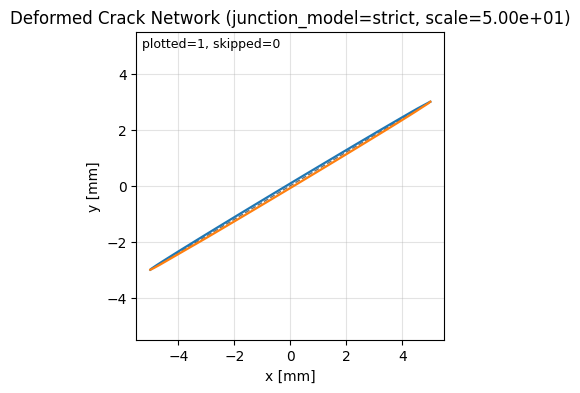

[cycle_00_initial] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_00_initial
[cycle_01 step_0001] grown_tips=2 | nV=4 | L=13.99 mm
[cycle_01 step_0002] grown_tips=2 | nV=6 | L=16.79 mm
[cycle_01 step_0003] grown_tips=2 | nV=8 | L=20.15 mm
[cycle_01 step_0004] grown_tips=2 | nV=10 | L=24.18 mm
[cycle_01 step_0005] grown_tips=2 | nV=12 | L=29.02 mm
[cycle_01 step_0006] grown_tips=2 | nV=14 | L=34.82 mm
[cycle_01 step_0007] grown_tips=2 | nV=16 | L=41.79 mm
[cycle_01 step_0008] grown_tips=2 | nV=18 | L=50.14 mm
[cycle_01 step_0009] grown_tips=2 | nV=20 | L=60.17 mm
[cycle_01] hit high-water vertex threshold: nV=20 >= 20
[cycle_01] post-simplify nV=20 (target ~12)


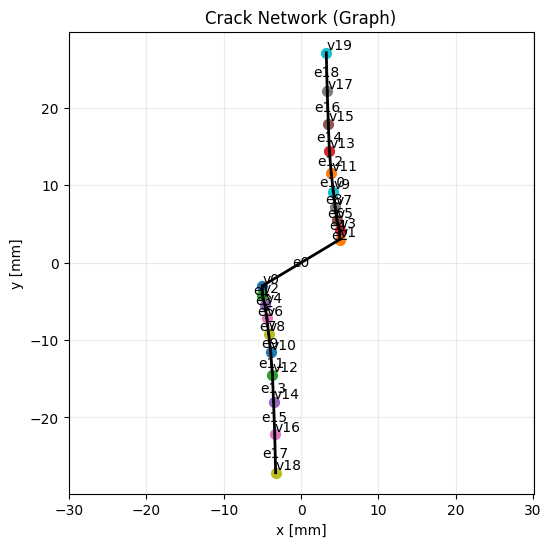

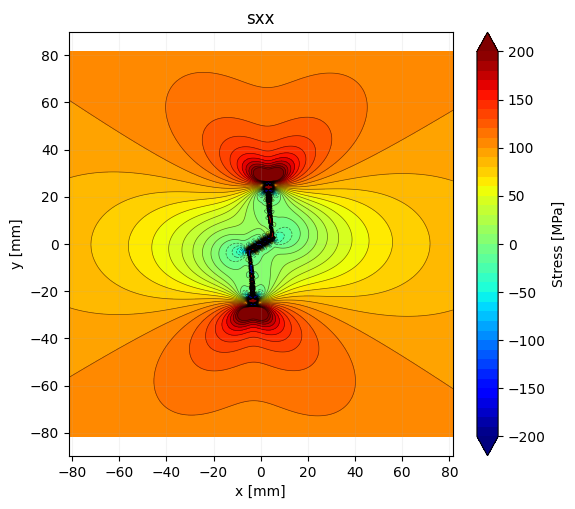

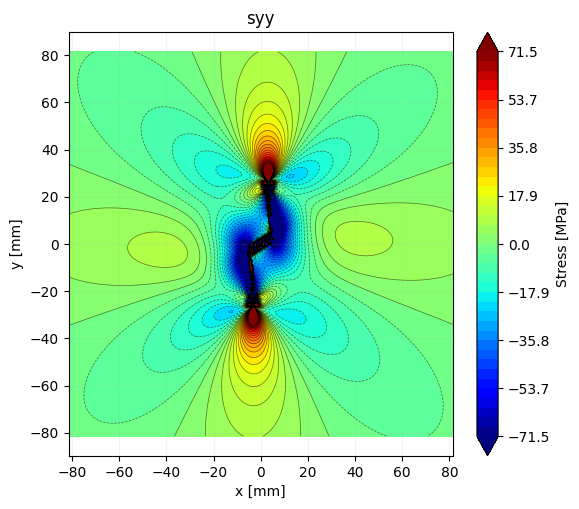

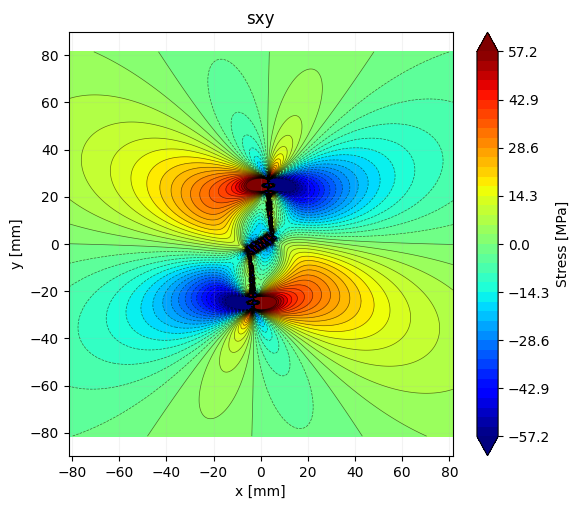

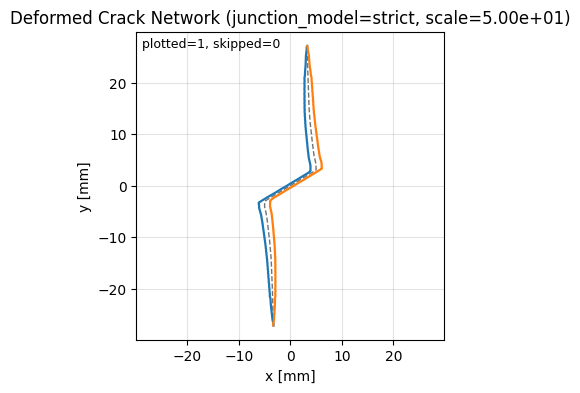

[cycle_01_step_0009_pre_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_01_step_0009_pre_simplify
✓ Loaded network: 20 vertices, 19 edges

SIMPLIFYING CRACK NETWORK
Initial: 20 vertices, 19 edges

Step 1: Merging nearby vertices...
  ✓ Merged 0 vertices

Step 2: Removing small edges...
  ✓ Removed 0 small edges

Step 3: Merging colinear edges...
  ✓ Merged 8 edge pairs

SIMPLIFICATION COMPLETE
Final: 12 vertices, 11 edges
Reduction: 8 vertices, 8 edges


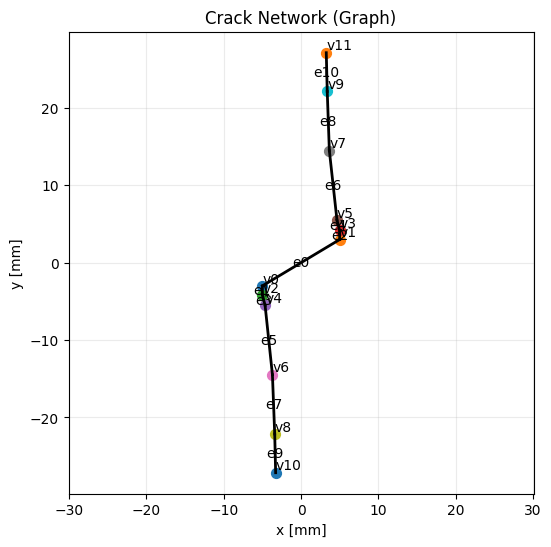

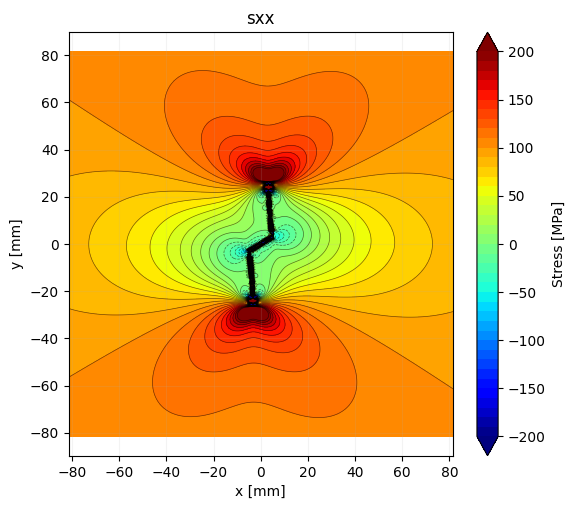

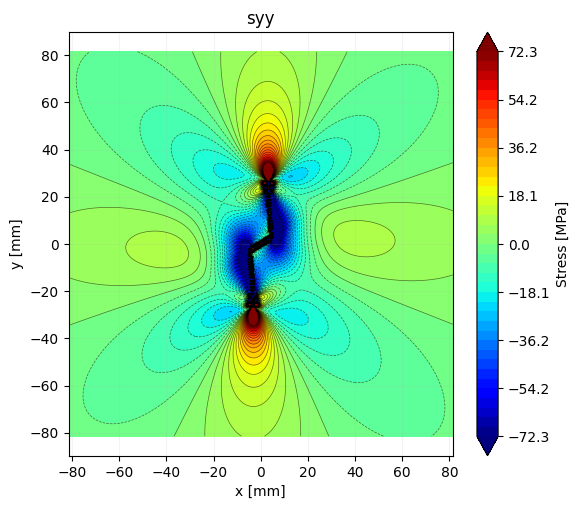

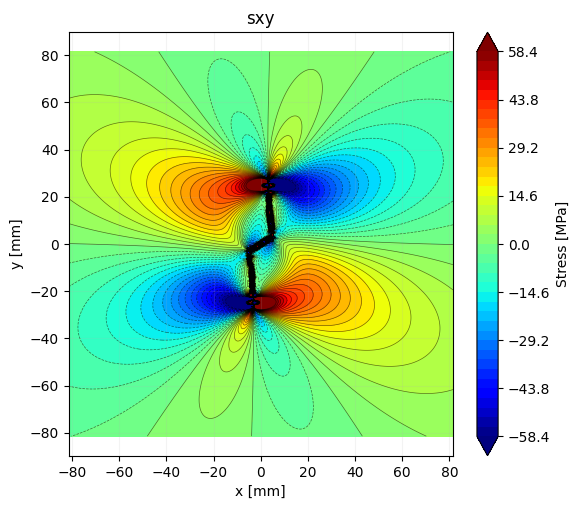

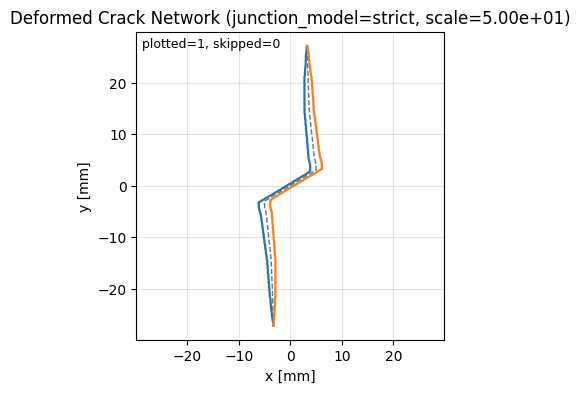

[cycle_01_step_0009_post_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_01_step_0009_post_simplify
[cycle_02 step_0010] grown_tips=2 | nV=14 | L=72.20 mm
[cycle_02 step_0011] grown_tips=2 | nV=16 | L=86.64 mm
[cycle_02 step_0012] grown_tips=2 | nV=18 | L=103.97 mm
[cycle_02 step_0013] grown_tips=2 | nV=20 | L=124.77 mm
[cycle_02] hit high-water vertex threshold: nV=20 >= 20
[cycle_02] post-simplify nV=12 (target ~12)


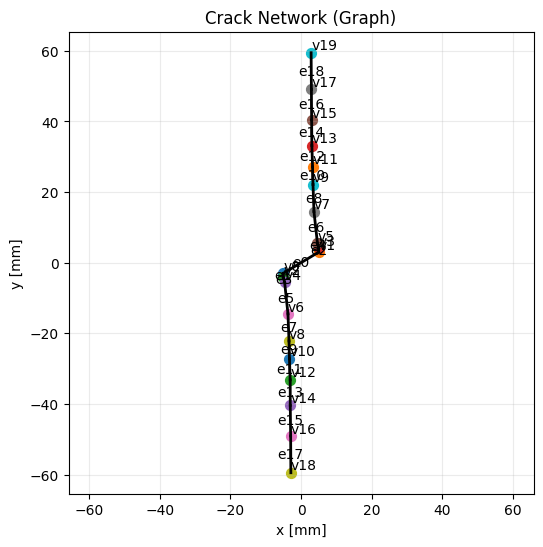

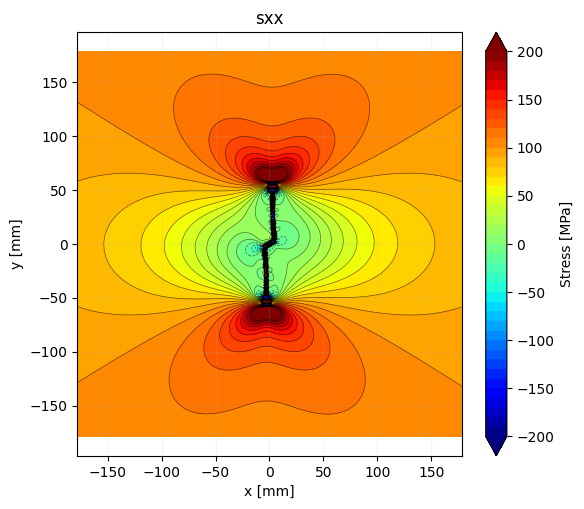

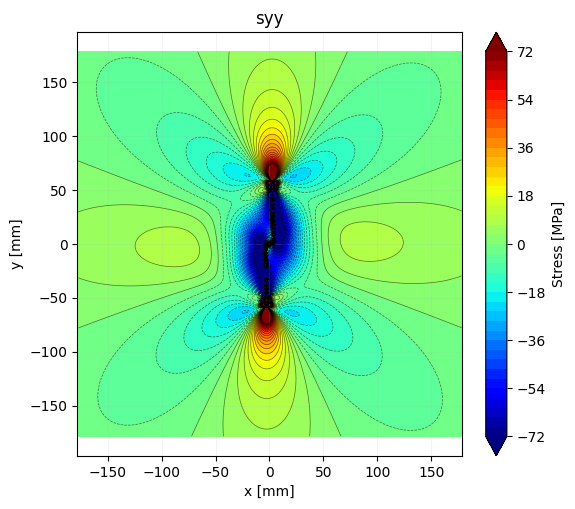

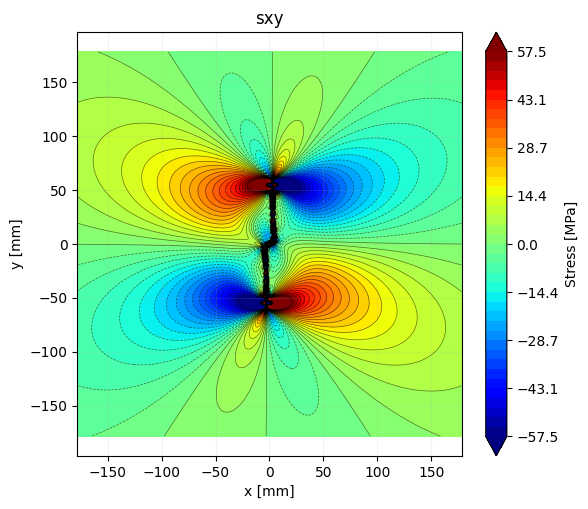

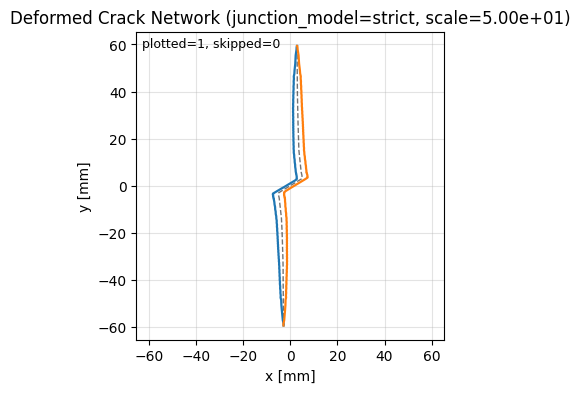

[cycle_02_step_0013_pre_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_02_step_0013_pre_simplify
✓ Loaded network: 20 vertices, 19 edges

SIMPLIFYING CRACK NETWORK
Initial: 20 vertices, 19 edges

Step 1: Merging nearby vertices...
  ✓ Merged 0 vertices

Step 2: Removing small edges...
  ✓ Removed 0 small edges

Step 3: Merging colinear edges...
  ✓ Merged 0 edge pairs

SIMPLIFICATION COMPLETE
Final: 20 vertices, 19 edges
Reduction: 0 vertices, 0 edges


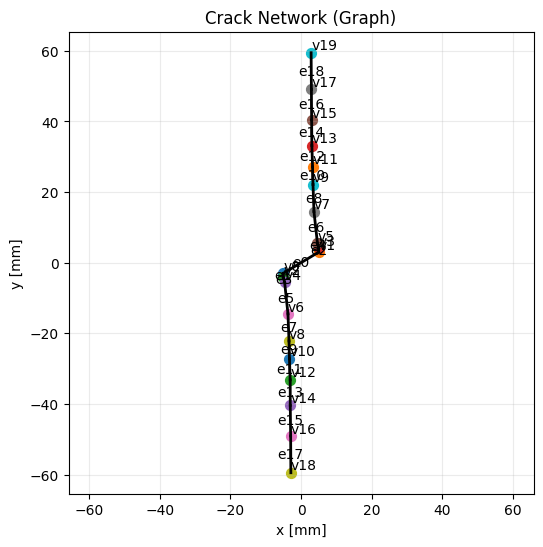

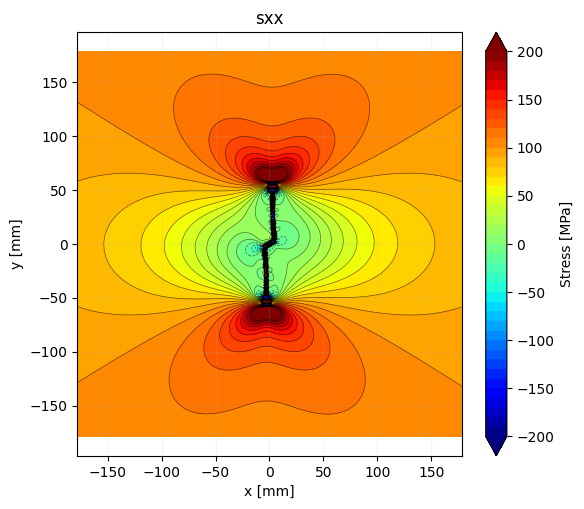

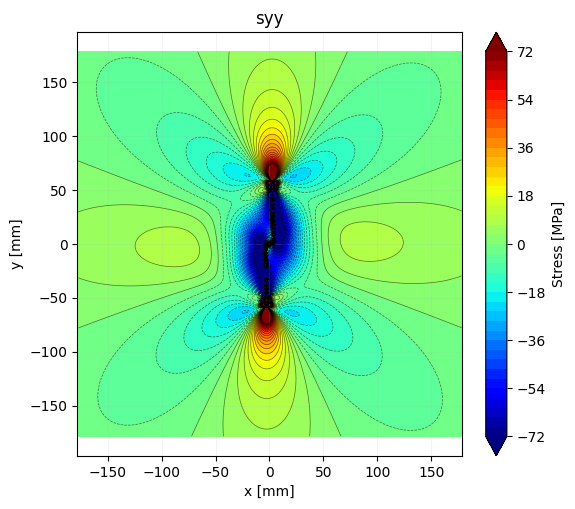

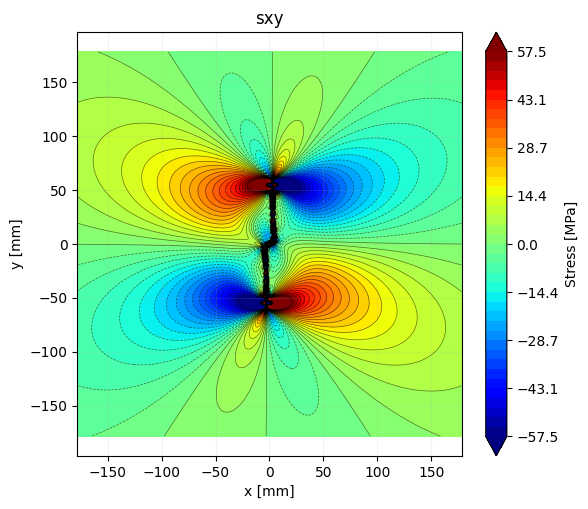

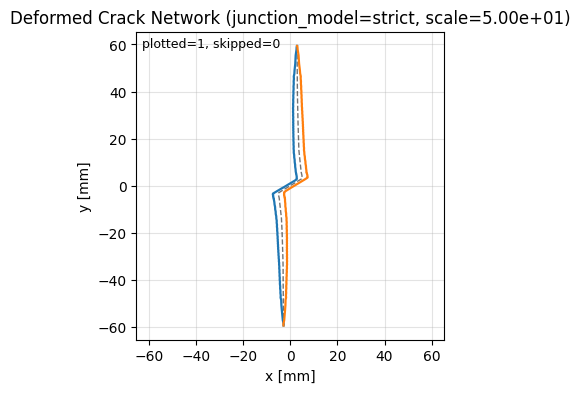

[cycle_02_step_0013_post_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_02_step_0013_post_simplify
[cycle_03 step_0014] grown_tips=2 | nV=22 | L=149.72 mm
[cycle_03] hit high-water vertex threshold: nV=22 >= 20
[cycle_03] post-simplify nV=20 (target ~12)


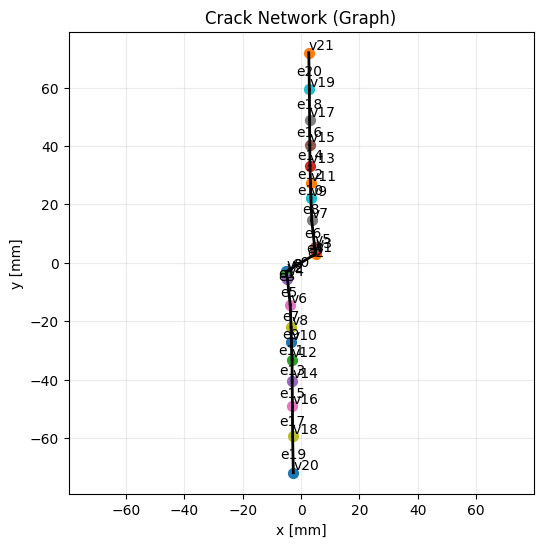

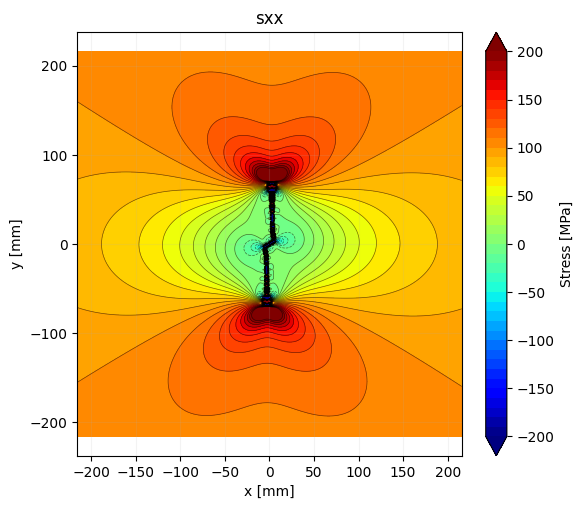

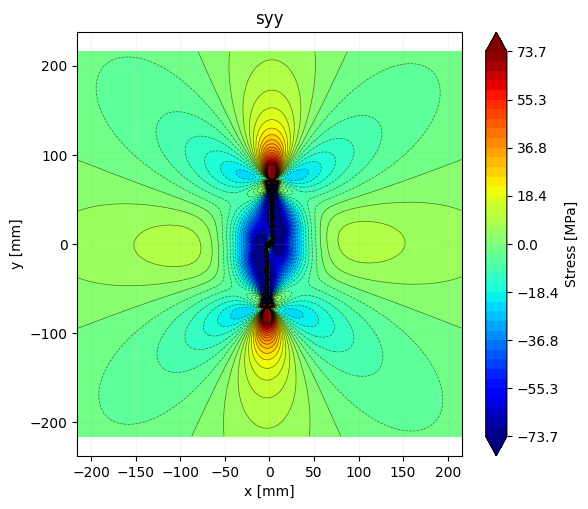

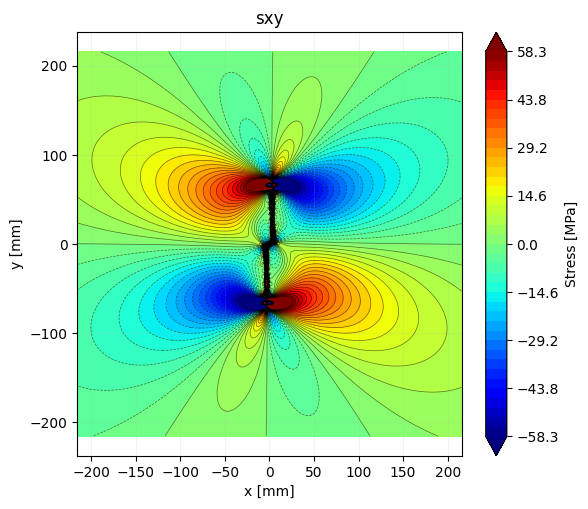

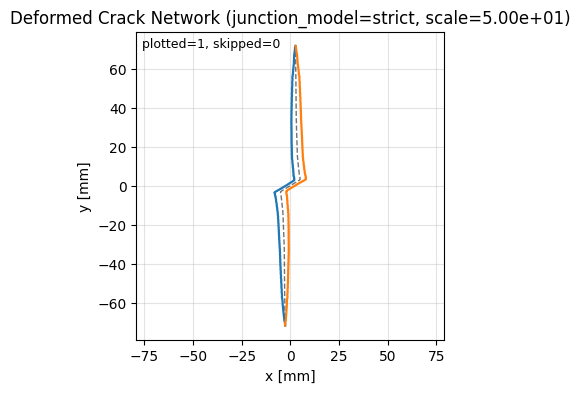

[cycle_03_step_0014_pre_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_03_step_0014_pre_simplify
✓ Loaded network: 22 vertices, 21 edges

SIMPLIFYING CRACK NETWORK
Initial: 22 vertices, 21 edges

Step 1: Merging nearby vertices...
  ✓ Merged 0 vertices

Step 2: Removing small edges...
  ✓ Removed 0 small edges

Step 3: Merging colinear edges...
  ✓ Merged 0 edge pairs

SIMPLIFICATION COMPLETE
Final: 22 vertices, 21 edges
Reduction: 0 vertices, 0 edges


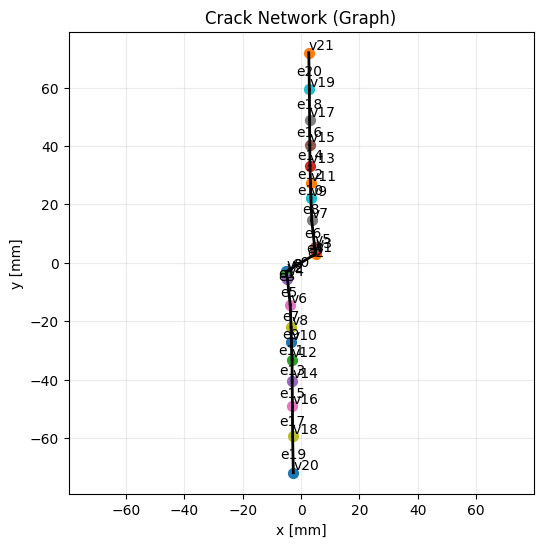

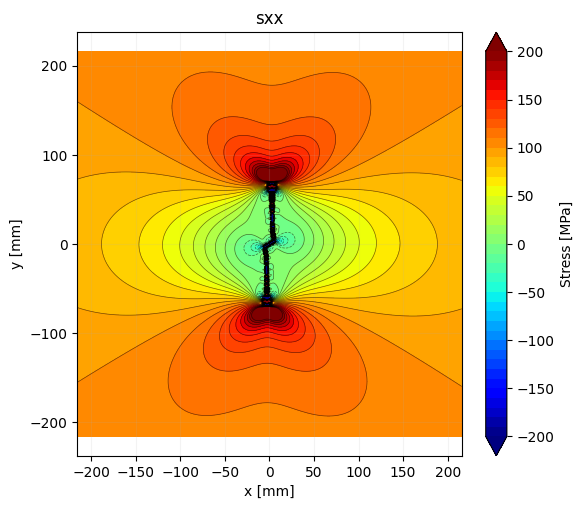

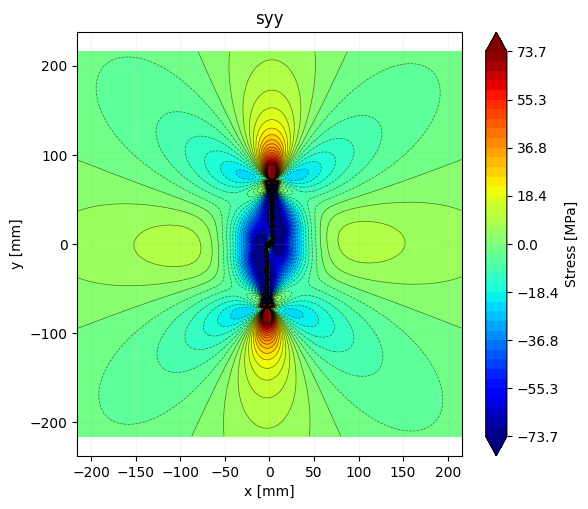

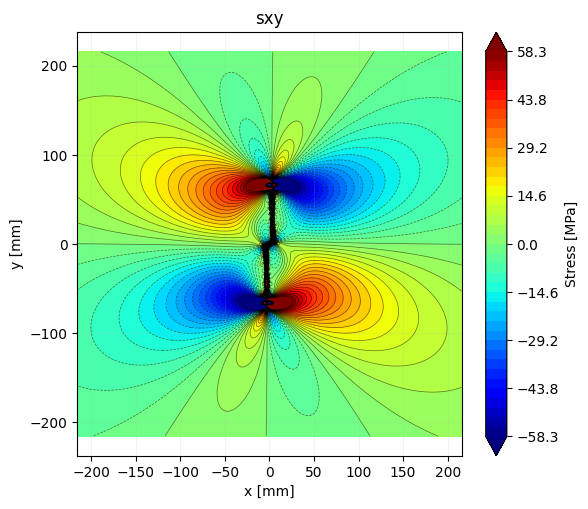

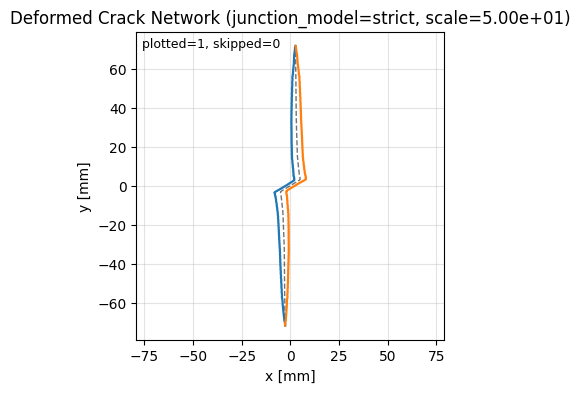

[cycle_03_step_0014_post_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_03_step_0014_post_simplify
[cycle_04 step_0015] grown_tips=2 | nV=24 | L=179.66 mm
[cycle_04] hit high-water vertex threshold: nV=24 >= 20
[cycle_04] post-simplify nV=22 (target ~12)


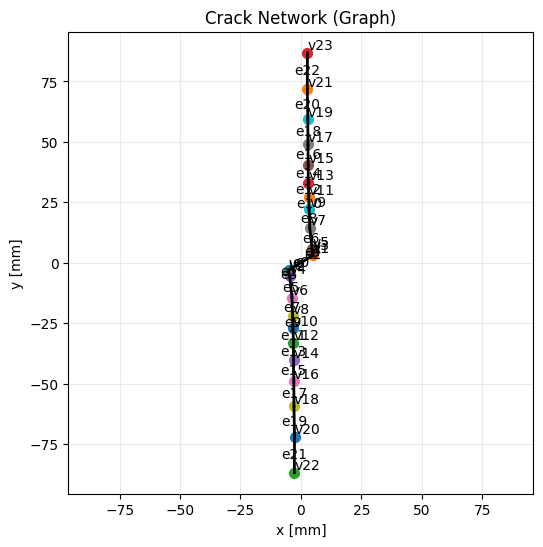

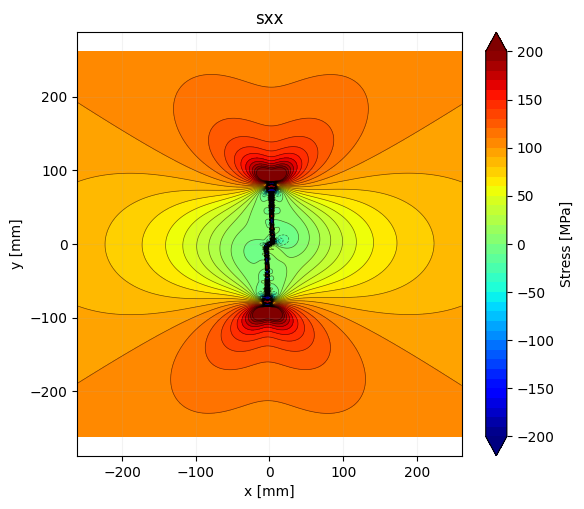

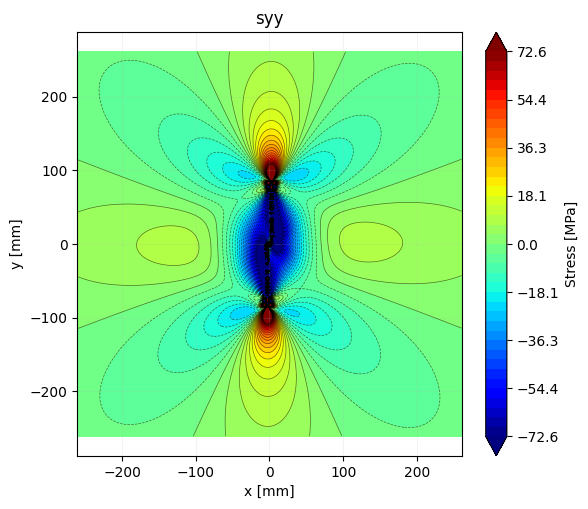

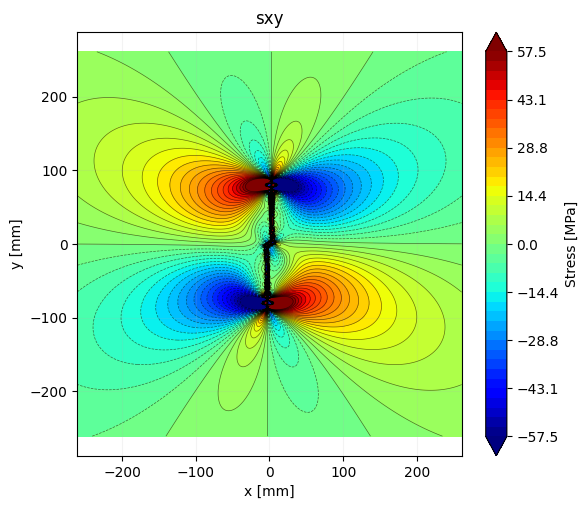

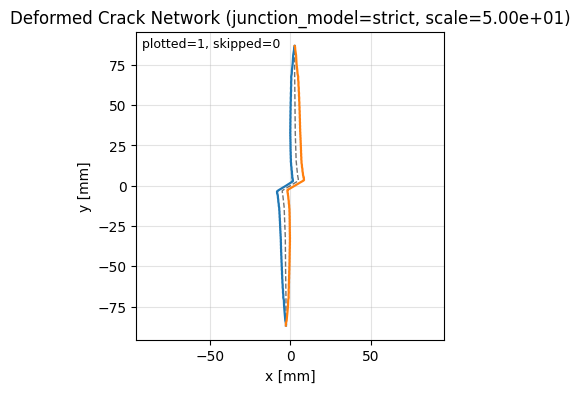

[cycle_04_step_0015_pre_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_04_step_0015_pre_simplify
✓ Loaded network: 24 vertices, 23 edges

SIMPLIFYING CRACK NETWORK
Initial: 24 vertices, 23 edges

Step 1: Merging nearby vertices...
  ✓ Merged 0 vertices

Step 2: Removing small edges...
  ✓ Removed 0 small edges

Step 3: Merging colinear edges...
  ✓ Merged 0 edge pairs

SIMPLIFICATION COMPLETE
Final: 24 vertices, 23 edges
Reduction: 0 vertices, 0 edges


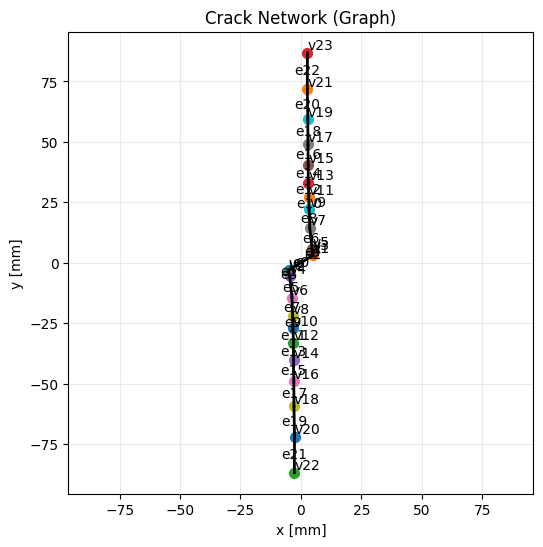

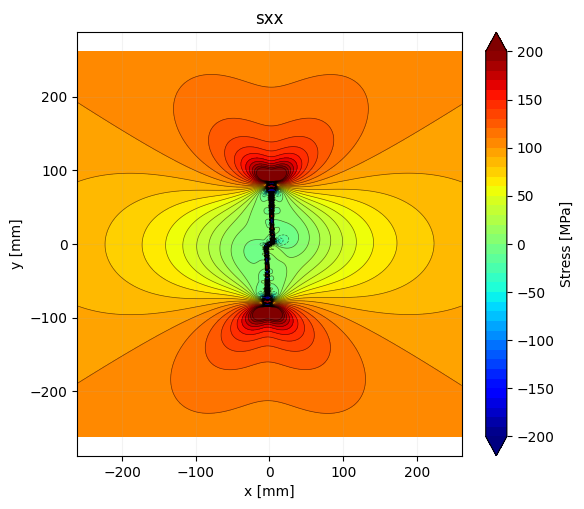

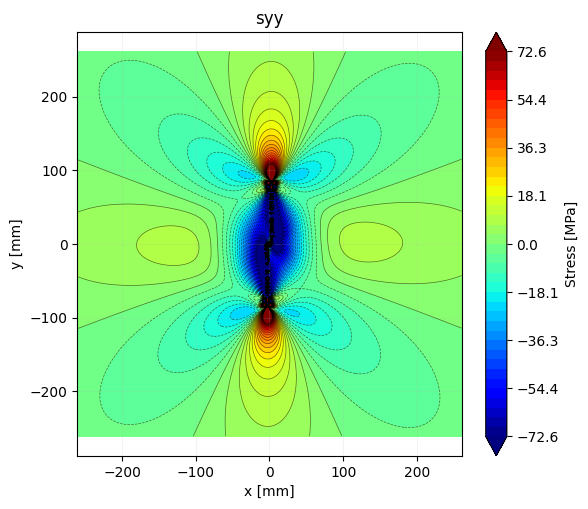

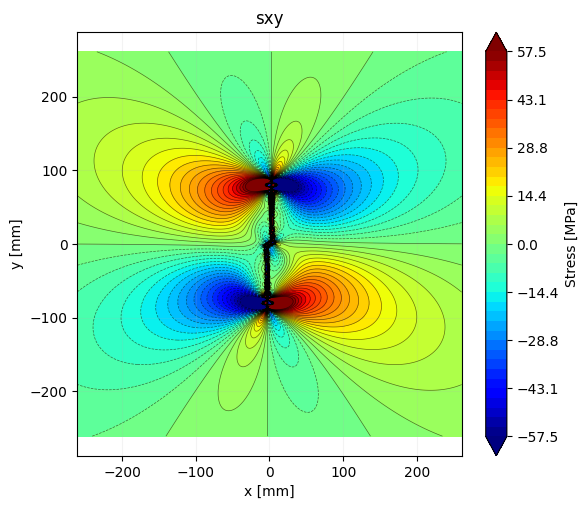

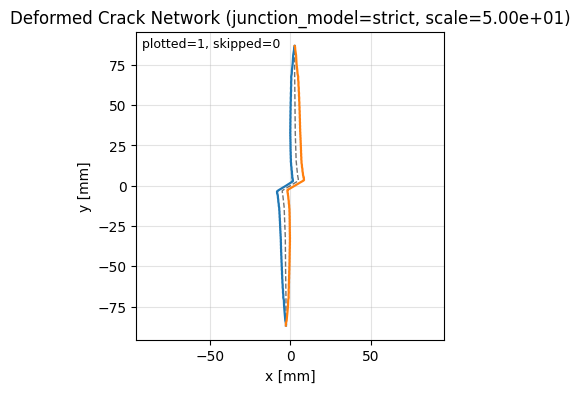

[cycle_04_step_0015_post_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_04_step_0015_post_simplify
[cycle_05 step_0016] grown_tips=2 | nV=26 | L=215.60 mm
[cycle_05] hit high-water vertex threshold: nV=26 >= 20
[cycle_05] post-simplify nV=24 (target ~12)


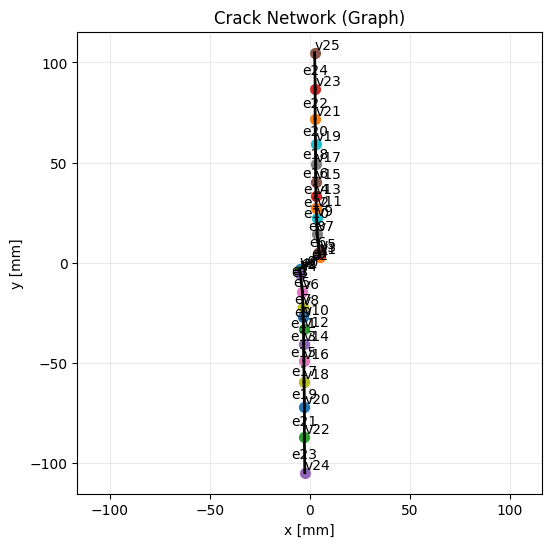

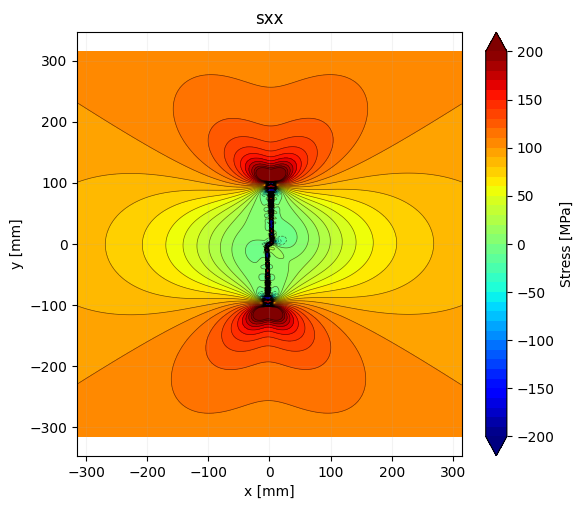

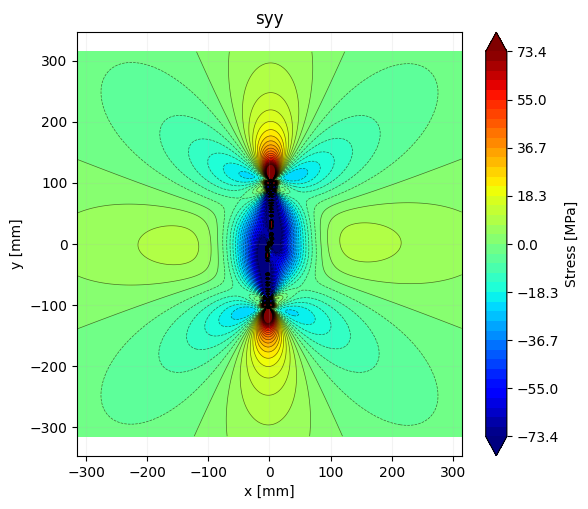

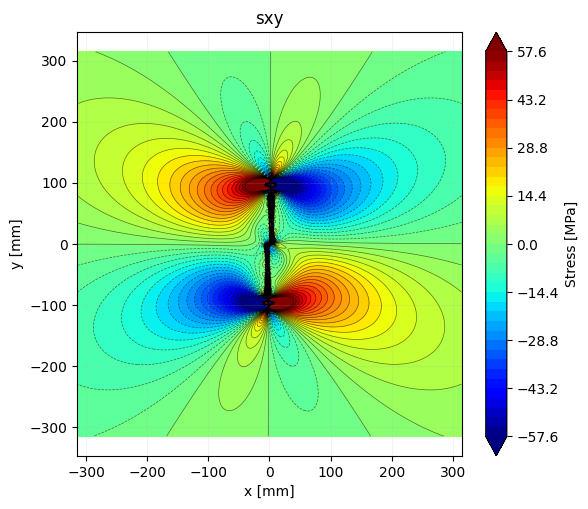

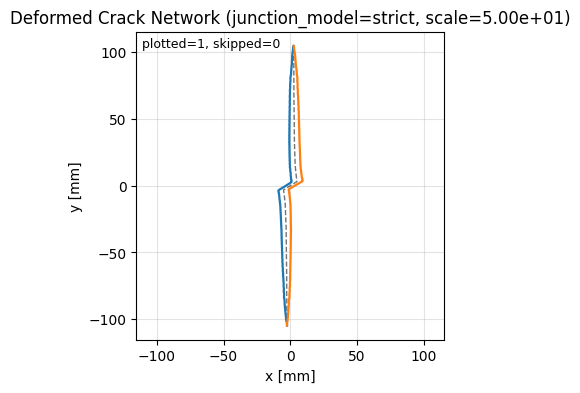

[cycle_05_step_0016_pre_simplify] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\cycle_05_step_0016_pre_simplify
[cycle_05] terminating outer loop (length reached).
Saved figures under: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation


In [ ]:
# ============================================================
# Kinked crack propagation demo + periodic simplification cycles
# - uses YOUR CrackNetworkSimplifier module (no re-implementation)
# - saves/plots at end of each outer cycle (pre/post simplify)
# ============================================================

import os, sys
from pathlib import Path
from collections import defaultdict, deque

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

# ---- USE YOUR MODULE (no scratch code)
from fracture_utils.Ugenerator.crack_network_simplifier import CrackNetworkSimplifier, SimplificationConfig

out_dir = Path(repo_root) / "output" / "KinkedCrackPropagation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build initial network
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  -3.0*mm],
    [1,    5.0*mm,   3.0*mm],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

net0 = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,          # NOTE: in your codebase this is NOT a vertex cap (you said it's max junction degree)
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=0.0e6, sigma_xy=0.0)

# ----------------------------
# ONE solver kwargs dict (used everywhere)
# ----------------------------
solver_kwargs = dict(
    ne_half=80,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
    # refinement rules
    refine_kinks=False,
    refine_junction_endpoints=False,
    # how much refinement
    endpoint_min_nodes=4,
    kink_side_nodes=1,
    # clustering shape
    tip_cluster="power",
    tip_cluster_power=2.5,
    # keep other segments from getting too coarse
    other_min_panels=4,
)

# ----------------------------
# Solve + plot (only when called)
# ----------------------------
def solve_and_plot(network, tag: str):
    step_dir = out_dir / tag
    step_dir.mkdir(parents=True, exist_ok=True)

    calc = DCENetworkStaticV4(material, network, applied)
    sol  = calc.solve(**solver_kwargs)
    res  = DCEResultsNetworkV4(calc, sol)

    plotter = DCEPlotterV4(res, out_dir=step_dir)
    _call(plotter, "plot_network_graph")

    opts = StressPlotOptsV4(
        extent_factor=3,
        n_grid=301,
        add_remote=True,
        mask_cracks=False,
        cmap="jet",
        n_bands=40,
        label_contours=False,
        vmax_factor=2,
    )
    _call(plotter, "plot_stress_components_global", opts=opts, components=("sxx", "syy", "sxy"))

    pl_def = DCEPlotterDeformedV4(res, out_dir=step_dir)
    _call(pl_def, "plot_deformed_network", scale=5e1, trim_core_junction_faces=True)

    plt.show()
    print(f"[{tag}] Saved figures to: {step_dir}")
    return res

# ----------------------------
# Propagation setup
# ----------------------------
cfg = PropagationConfig(f0=0.10, f_fixed=0.1,
                        step_mode="fixed_step", simultaneous_tip_growth=True)

Kc_demo = 1e6  # Pa*sqrt(m)
tough = ConstantToughness(Kc_demo)

dir_law = MaximumHoopStressLaw()

evaluator = CandidateEvaluator(
    material=material,
    applied=applied,
    solver_kwargs=solver_kwargs,          # same dict
    direction_law=dir_law,
    enable_ne_half_escalation=False,
)
evaluator.rmax_frac = 0.25
evaluator.min_pts   = 8

prop = CrackPropagator(
    cfg=cfg,
    evaluator=evaluator,
    toughness=tough,
    direction_law=dir_law,
)

# ============================================================
# Helpers: export network + chain length (single polyline)
# ============================================================
def net_to_arrays(net: CrackNetworkV4):
    V = np.array([[int(v.id), float(v.x), float(v.y)] for v in net.vertices], dtype=float)
    C = np.array([[int(e.v0), int(e.v1)] for e in net.edges], dtype=int)
    return V, C

def chain_order_from_connectivity(C):
    adj = defaultdict(list)
    deg = defaultdict(int)
    for a, b in C:
        a = int(a); b = int(b)
        adj[a].append(b); adj[b].append(a)
        deg[a] += 1; deg[b] += 1
    tips = [vid for vid, d in deg.items() if d == 1]
    start = tips[0] if tips else int(C[0, 0])
    order = []
    prev = None
    cur = start
    while True:
        order.append(cur)
        nbrs = adj[cur]
        nxt = None
        if prev is None:
            nxt = nbrs[0] if nbrs else None
        else:
            cand = [x for x in nbrs if x != prev]
            nxt = cand[0] if cand else None
        if nxt is None:
            break
        prev, cur = cur, nxt
        if len(order) > len(adj) + 5:
            break
    return order

def polyline_length_mm_from_arrays(V, C):
    if C.size == 0:
        return 0.0
    xy = {int(row[0]): np.array([row[1], row[2]], float) for row in V}
    order = chain_order_from_connectivity(C)
    L = 0.0
    for i in range(len(order) - 1):
        L += float(np.linalg.norm(xy[order[i+1]] - xy[order[i]]))
    return L / mm

# ============================================================
# Outer-cycle controls
# ============================================================
vertex_limit = 20        # stop inner loop when this many vertices reached
L_limit_mm   = 200.0     # stop ALL when length reaches this
max_cycles   = 50       # safety

simp_cfg = SimplificationConfig(
    max_angle_deviation=3.0,
    min_edge_length=0.25*mm,
    remove_degree2_nodes=False,
    merge_at_degree2=True,
    merge_vertex_tolerance=1e-6,
    max_merged_edge_length=10*mm,
    preserve_tips=True,
    preserve_junctions=True
)

# ----------------------------
# Plot INITIAL
# ----------------------------
solve_and_plot(net0, tag="cycle_00_initial")

# ----------------------------
# Outer-cycle loop
# ----------------------------
net = net0
global_step = 0


for cyc in range(1, max_cycles + 1):

    # ---- inner loop: run until vertex_limit or no-growth or length limit
    vertex_high = 20   # trigger simplify when reached/exceeded
    vertex_low  = 12   # desired post-simplify size (guide; simplifier may not hit exactly)

    did_grow_this_cycle = False

    while True:
        # Stop by length first
        V_now, C_now = net_to_arrays(net)
        Lmm = polyline_length_mm_from_arrays(V_now, C_now)
        if Lmm >= L_limit_mm:
            print(f"[cycle_{cyc:02d}] reached length limit: L={Lmm:.2f} mm")
            break

        # --- Always attempt a growth step first ---
        result = prop.grow_one_increment(net)
        net = result.network_new

        grew = sum(1 for r in result.reports if bool(getattr(r, "grew", False)))
        global_step += 1
        did_grow_this_cycle |= (grew > 0)

        # recompute nV AFTER growth
        V_now, C_now = net_to_arrays(net)
        nV = V_now.shape[0]
        Lmm = polyline_length_mm_from_arrays(V_now, C_now)

        print(f"[cycle_{cyc:02d} step_{global_step:04d}] grown_tips={grew} | nV={nV} | L={Lmm:.2f} mm")

        if grew == 0:
            print(f"[cycle_{cyc:02d}] No tips exceeded toughness. Stopping.")
            break

        # Trigger simplification only AFTER we’ve actually grown
        if nV >= vertex_high:
            print(f"[cycle_{cyc:02d}] hit high-water vertex threshold: nV={nV} >= {vertex_high}")
            break

    V_post, C_post = simplifier.to_arrays()
    print(f"[cycle_{cyc:02d}] post-simplify nV={len(V_post)} (target ~{vertex_low})")

    # ---- end-of-cycle outputs (PRE-simplify)
    V_pre, C_pre = net_to_arrays(net)
    Lmm_pre = polyline_length_mm_from_arrays(V_pre, C_pre)

    cyc_dir = out_dir / f"cycle_{cyc:02d}"
    cyc_dir.mkdir(parents=True, exist_ok=True)

    np.savez(cyc_dir / f"network_pre_simplify_step_{global_step:04d}.npz",
             vertices=V_pre, connectivity=C_pre)

    solve_and_plot(net, tag=f"cycle_{cyc:02d}_step_{global_step:04d}_pre_simplify")

    # stop all cycles if length reached or no growth
    if Lmm_pre >= L_limit_mm:
        print(f"[cycle_{cyc:02d}] terminating outer loop (length reached).")
        break

    # If the last inner step ended due to no-growth, stop (do not simplify)
    if 'result' in locals():
        grew_last = sum(1 for r in result.reports if bool(getattr(r, "grew", False)))
        if grew_last == 0:
            print(f"[cycle_{cyc:02d}] terminating outer loop (no growth).")
            break

    # ---- simplify using YOUR MODULE
    simplifier = CrackNetworkSimplifier(config=simp_cfg)
    simplifier.load_from_arrays(V_pre, C_pre)
    simp_stats = simplifier.simplify(verbose=True)
    V_post, C_post = simplifier.to_arrays()

    np.savez(cyc_dir / f"network_post_simplify_step_{global_step:04d}.npz",
             vertices=V_post, connectivity=C_post)

    # rebuild CrackNetworkV4 from simplified arrays and continue
    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=V_post,
        connectivity=C_post,
        Nv_max=4,        # keep your junction-degree cap consistent
        validate=True
    )

    solve_and_plot(net, tag=f"cycle_{cyc:02d}_step_{global_step:04d}_post_simplify")

print("Saved figures under:", out_dir)


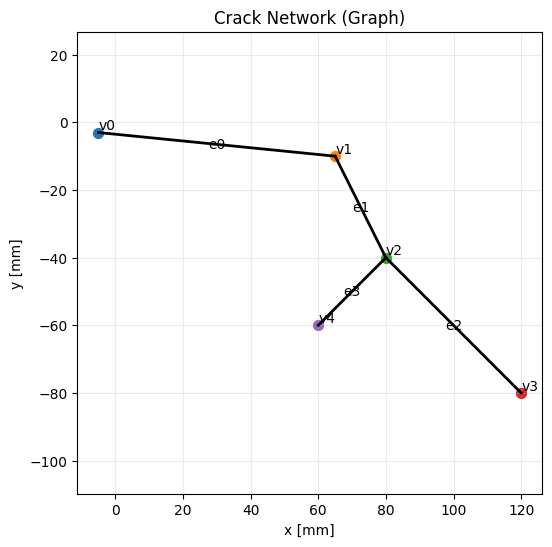

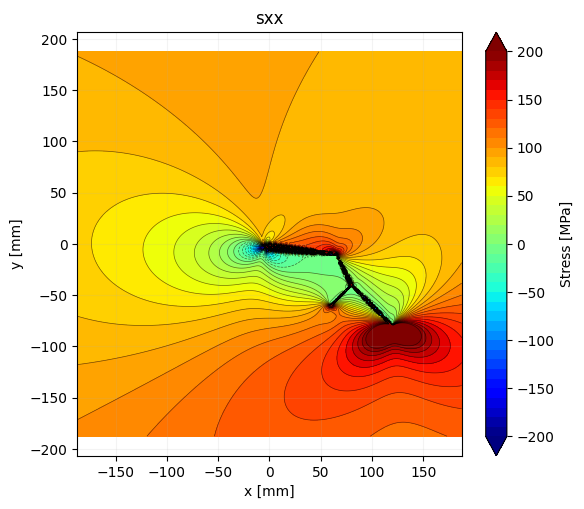

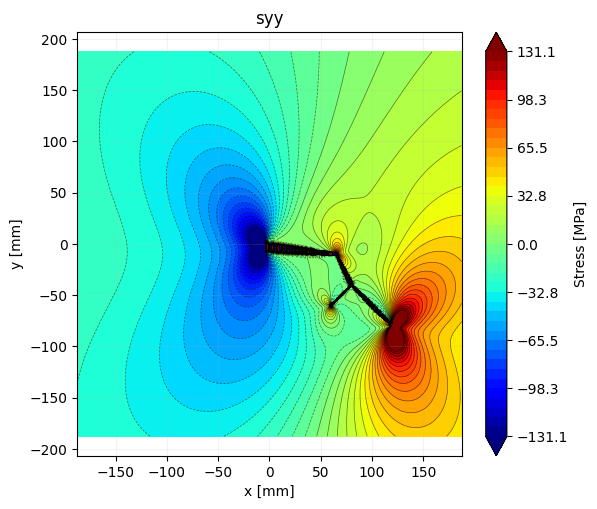

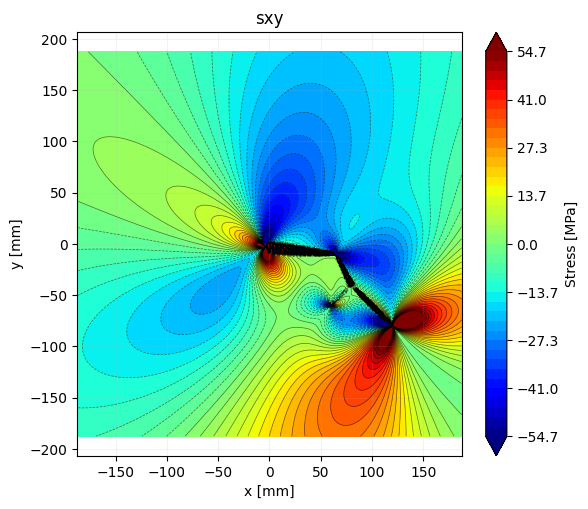

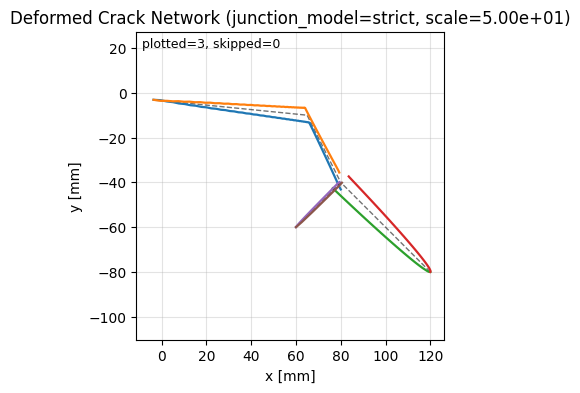

[step_00_initial] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\step_00_initial
[step_01] grown_tips=3
[step_02] grown_tips=3
[step_03] grown_tips=3
[step_04] grown_tips=3
[step_05] grown_tips=3
[step_06] grown_tips=3
[step_07] grown_tips=3
[step_08] grown_tips=3
[step_09] grown_tips=3
[step_10] grown_tips=3
[step_11] grown_tips=3
[step_12] grown_tips=3
[step_13] grown_tips=3
[step_14] grown_tips=3
[step_15] grown_tips=3


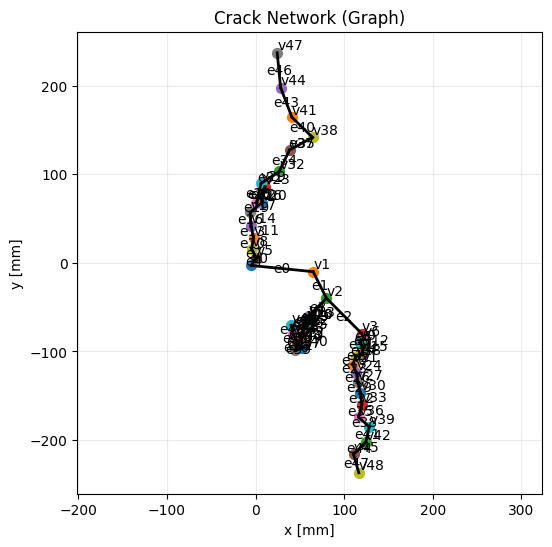

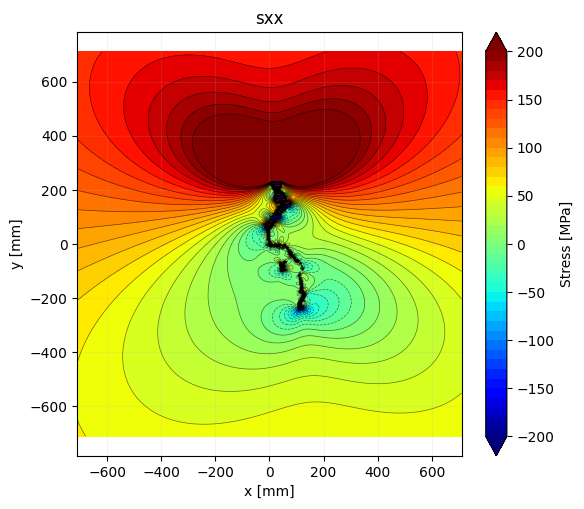

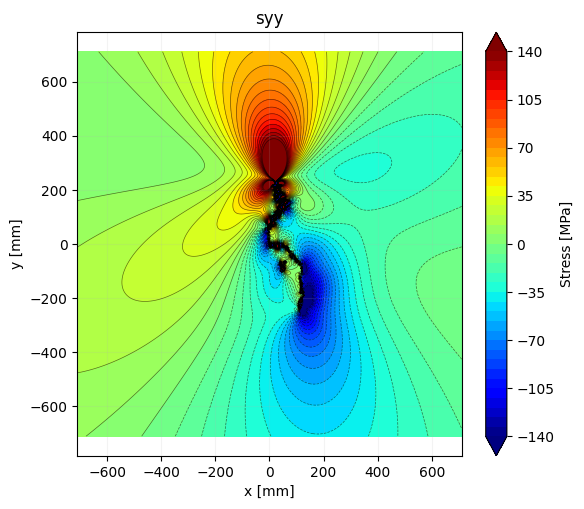

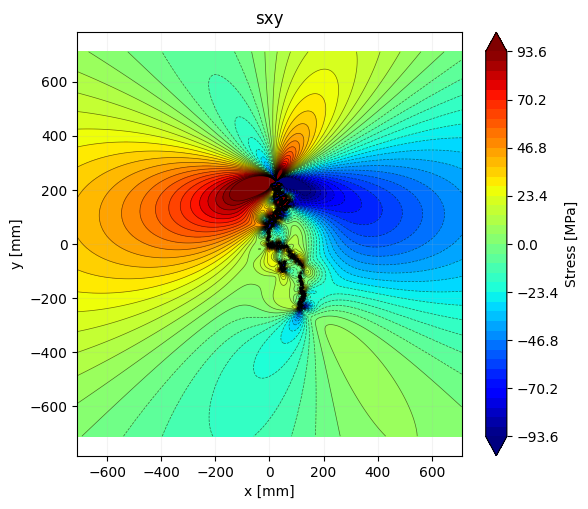

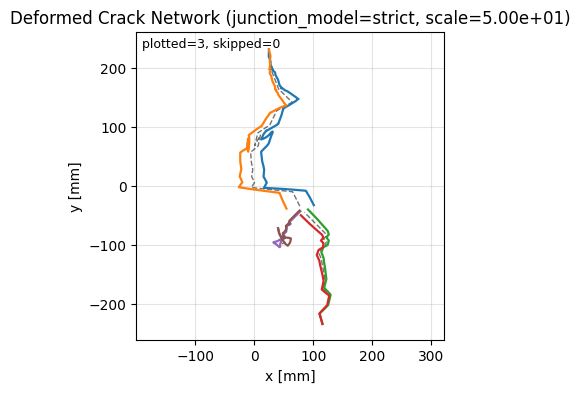

[step_15_final] Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation\step_15_final
Saved figures under: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation


In [2]:
# ============================================================
# Two kinked cracks propagation demo
# - single solver_kwargs source of truth
# - plots only initial and final states
# ============================================================

import os, sys
from pathlib import Path

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "KinkedCrackPropagation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build initial network
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,  -5.0*mm,  -3.0*mm],
    [1 ,  65.0*mm, -10*mm],
    [2,  80.0*mm, -40.0*mm],
    [3,  120.0*mm, -80.0*mm],
    [4, 60.0*mm, -60.0*mm]
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],
    [2, 3],
    [2, 4],
], dtype=int)


net0 = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=0.0e6, sigma_xy=0.0)

# ----------------------------
# ONE solver kwargs dict (used everywhere)
# ----------------------------
solver_kwargs = dict(
    ne_half=60,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
    # refinement rules
    refine_kinks=True,
    refine_junction_endpoints=True,
    # how much refinement
    endpoint_min_nodes=4,     # was effectively ~6
    kink_side_nodes=1,         # was 2 in current solver defaults
    # clustering shape
    tip_cluster="power",
    tip_cluster_power=2.5,
    # keep other segments from getting too coarse
    other_min_panels=4,
)

# ----------------------------
# Solve + plot (only when called)
# ----------------------------
def solve_and_plot(network, tag: str):
    step_dir = out_dir / tag
    step_dir.mkdir(parents=True, exist_ok=True)

    calc = DCENetworkStaticV4(material, network, applied)
    sol  = calc.solve(**solver_kwargs)
    res  = DCEResultsNetworkV4(calc, sol)

    plotter = DCEPlotterV4(res, out_dir=step_dir)
    _call(plotter, "plot_network_graph")

    opts = StressPlotOptsV4(
        extent_factor=3,
        n_grid=301,
        add_remote=True,
        mask_cracks=False,
        cmap="jet",
        n_bands=40,
        label_contours=False,
        vmax_factor=2,
    )
    _call(plotter, "plot_stress_components_global", opts=opts, components=("sxx", "syy", "sxy"))

    pl_def = DCEPlotterDeformedV4(res, out_dir=step_dir)
    _call(pl_def, "plot_deformed_network", scale=5e1, trim_core_junction_faces=True)

    plt.show()
    print(f"[{tag}] Saved figures to: {step_dir}")
    return res

# ----------------------------
# Propagation setup
# ----------------------------
cfg = PropagationConfig(f0=0.10, f_fixed=0.1, 
                        step_mode="fixed_step", simultaneous_tip_growth=True)

Kc_demo = 1e6  # Pa*sqrt(m)
tough = ConstantToughness(Kc_demo)

dir_law = MaximumHoopStressLaw()


evaluator = CandidateEvaluator(
    
    material=material,
    applied=applied,
    solver_kwargs=solver_kwargs,   # <-- same dict
    direction_law=dir_law,
    enable_ne_half_escalation=False,  # <-- allow more accurate SIFs during propagation if needed    
)

prop = CrackPropagator(
    cfg=cfg,
    evaluator=evaluator,
    toughness=tough,
    direction_law=dir_law,
)

# ----------------------------
# Plot INITIAL
# ----------------------------
solve_and_plot(net0, tag="step_00_initial")

# ----------------------------
# Propagate (NO plotting during loop)
# ----------------------------
n_steps = 15
net = net0

for k in range(1, n_steps + 1):
    result = prop.grow_one_increment(net)
    net = result.network_new

    grew = sum(1 for r in result.reports if bool(getattr(r, "grew", False)))
    print(f"[step_{k:02d}] grown_tips={grew}")

    if grew == 0:
        print("No tips exceeded toughness. Stopping.")
        break

# ----------------------------
# Plot FINAL
# ----------------------------
solve_and_plot(net, tag=f"step_{k:02d}_final")
print("Saved figures under:", out_dir)


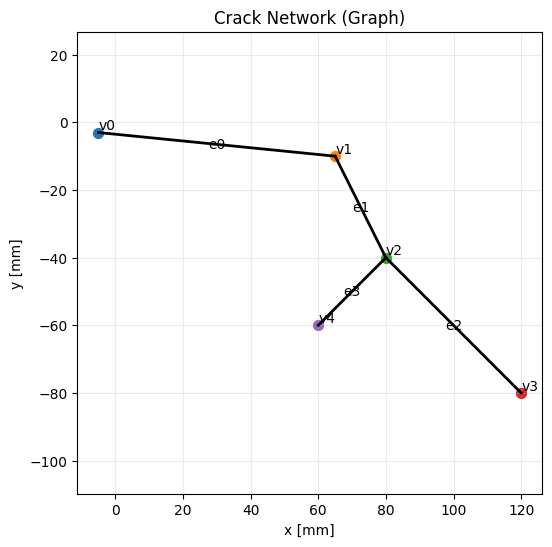

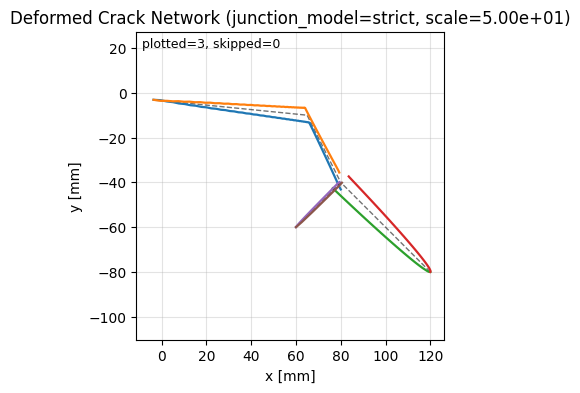

[step_01] grew=True | L_ref=103.89 mm | ds_ref=10.389 mm
[step_02] grew=True | L_ref=114.28 mm | ds_ref=11.428 mm
[step_03] grew=True | L_ref=152.48 mm | ds_ref=15.248 mm
[step_04] grew=True | L_ref=179.07 mm | ds_ref=17.907 mm
[step_05] grew=True | L_ref=196.97 mm | ds_ref=19.697 mm
[step_06] grew=True | L_ref=252.02 mm | ds_ref=25.202 mm


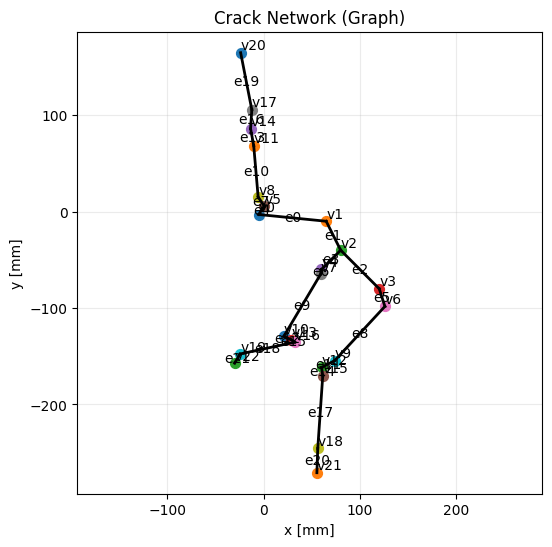

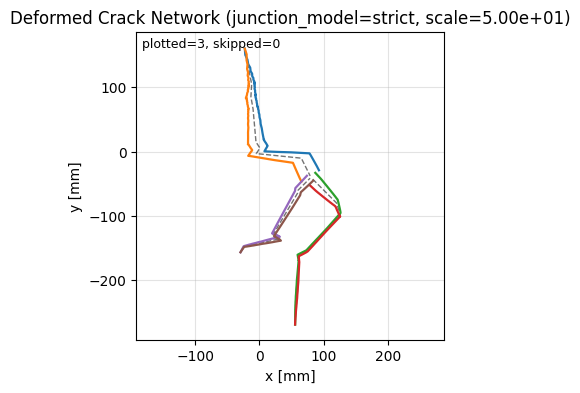

Saved under: C:\Users\Owner\Documents\Repos\Fracture\VCM_2_2\output\KinkedCrackPropagation


In [2]:
# ============================================================
# Two kinked cracks propagation demo
# - multi-component, K-scaled fixed-step growth
# ============================================================

import os, sys
from pathlib import Path
import numpy as np

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

# IMPORTANT: use your updated network_ops
from fracture_utils.Upropagation.network_ops import extract_open_polylines

out_dir = Path(repo_root) / "output" / "KinkedCrackPropagation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build initial network
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,  -5.0*mm,  -3.0*mm],
    [1 ,  65.0*mm, -10*mm],
    [2,  80.0*mm, -40.0*mm],
    [3, 120.0*mm, -80.0*mm],
    [4,  60.0*mm, -60.0*mm],
], dtype=float)

connectivity = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [2, 4],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=0.0, sigma_xy=0.0)

# ----------------------------
# Solver kwargs
# ----------------------------
solver_kwargs = dict(
    ne_half=60,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
    refine_kinks=True,
    refine_junction_endpoints=True,
    endpoint_min_nodes=4,
    kink_side_nodes=1,
    tip_cluster="power",
    tip_cluster_power=2.5,
    other_min_panels=4,
)

# ----------------------------
# Plot helper
# ----------------------------
def solve_and_plot(network, tag):
    step_dir = out_dir / tag
    step_dir.mkdir(parents=True, exist_ok=True)

    calc = DCENetworkStaticV4(material, network, applied)
    sol  = calc.solve(**solver_kwargs)
    res  = DCEResultsNetworkV4(calc, sol)

    plotter = DCEPlotterV4(res, out_dir=step_dir)
    _call(plotter, "plot_network_graph")

    pl_def = DCEPlotterDeformedV4(res, out_dir=step_dir)
    _call(pl_def, "plot_deformed_network", scale=5e1, trim_core_junction_faces=True)

    plt.show()
    return res

# ----------------------------
# Propagation setup
# ----------------------------
cfg = PropagationConfig(
    f0=0.10,
    f_fixed=0.10,
    step_mode="fixed_step",
    simultaneous_tip_growth=True
)

tough = ConstantToughness(1e6)
dir_law = MaximumHoopStressLaw()

evaluator = CandidateEvaluator(
    material=material,
    applied=applied,
    solver_kwargs=solver_kwargs,
    direction_law=dir_law,
    enable_ne_half_escalation=False,
)

prop = CrackPropagator(
    cfg=cfg,
    evaluator=evaluator,
    toughness=tough,
    direction_law=dir_law,
)

# ----------------------------
# INITIAL
# ----------------------------
solve_and_plot(net, "step_00_initial")

# ============================================================
# MULTI-COMPONENT SCALED GROWTH LOOP
# ============================================================
n_steps = 6

from fracture_utils.Upropagation.network_ops import get_netops

netops = get_netops()

for k in range(1, n_steps + 1):

    deg = netops.degree_map(net)
    polylines = netops.extract_open_polylines(net)

    if not polylines:
        print("No polylines found.")
        break

    # ---- baseline solve ONCE
    base_res = evaluator.solve_results(net)

    poly_data = []

    for pl in polylines:
        tips = netops.extract_deg1_tips(net, [pl], deg) or []
        if not tips:
            continue

        # there can be 1 or 2 tips associated with a polyline (tip–tip or tip–junction)
        # We'll evaluate both and pick the larger Keff as that polyline’s representative driver.
        tip_keffs = []
        for tip in tips:
            tev = evaluator.eval_tip(base_res, tip)
            tip_keffs.append((tip, float(tev.keff), float(tev.theta)))

        tip, keff, theta = max(tip_keffs, key=lambda x: x[1])

        # polyline length from vids
        L = 0.0
        vmap = {int(v.id): np.array([float(v.x), float(v.y)]) for v in net.vertices}
        for i in range(len(pl.vids) - 1):
            a = int(pl.vids[i]); b = int(pl.vids[i+1])
            L += float(np.linalg.norm(vmap[b] - vmap[a]))

        poly_data.append(dict(poly=pl, tip=tip, keff=keff, theta=theta, length=L))

    if not poly_data:
        print("No active tips.")
        break

    # ---- reference component = longest
    ref = max(poly_data, key=lambda d: d["length"])
    L_ref = float(ref["length"])
    K_ref = max(float(ref["keff"]), 1e-12)

    ds_ref = cfg.f_fixed * L_ref

    # ---- apply growth (scaled by Keff ratio)
    updater = prop._get_updater()  # uses your internal updater
    net_new = net
    grew_any = False

    for d in poly_data:
        rel = float(d["keff"]) / K_ref
        ds = ds_ref * rel
        if ds <= 0.0:
            continue

        net_new = updater.extend_tip(
            net_new,
            d["tip"],
            theta=float(d["theta"]),
            delta_a=float(ds)
        )
        grew_any = True

    net = net_new

    print(
        f"[step_{k:02d}] grew={grew_any} | "
        f"L_ref={L_ref/mm:.2f} mm | ds_ref={ds_ref/mm:.3f} mm"
    )

    if not grew_any:
        print("No growth accepted. Stopping.")
        break


# ----------------------------
# FINAL
# ----------------------------
solve_and_plot(net, f"step_{k:02d}_final")
print("Saved under:", out_dir)


In [ ]:
# ============================================================
# Kinked crack propagation demo (via network_growth.py)
# - single solver_kwargs source of truth
# - plots only initial and final states (same as before)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "KinkedCrackPropagation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build initial network
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  -3.0*mm],
    [1,    5.0*mm,   3.0*mm],
    [2,   -7.0*mm, -10*mm],
    [3,   8.0*mm, 4.0*mm],
    [4,  0.0*mm, 8.0*mm],
    [5,  10.0*mm, -5.0*mm],

], dtype=float)

connectivity = np.array([[0, 1],[2, 3],[4, 5]], dtype=int)

net0 = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=0.0e6, sigma_xy=0.0)

# ----------------------------
# ONE solver kwargs dict (used everywhere)
# ----------------------------
solver_kwargs = dict(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
    # refinement rules
    refine_kinks=False,
    refine_junction_endpoints=False,
    # how much refinement
    endpoint_min_nodes=4,
    kink_side_nodes=1,
    # clustering shape
    tip_cluster="power",
    tip_cluster_power=2.5,
    # keep other segments from getting too coarse
    other_min_panels=4,
)

# ----------------------------
# Solve + plot (only when called)
# ----------------------------
def solve_and_plot(network, tag: str):
    step_dir = out_dir / tag
    step_dir.mkdir(parents=True, exist_ok=True)

    calc = DCENetworkStaticV4(material, network, applied)
    sol  = calc.solve(**solver_kwargs)
    res  = DCEResultsNetworkV4(calc, sol)

    plotter = DCEPlotterV4(res, out_dir=step_dir)
    _call(plotter, "plot_network_graph")

    opts = StressPlotOptsV4(
        extent_factor=3,
        n_grid=301,
        add_remote=True,
        mask_cracks=False,
        cmap="jet",
        n_bands=40,
        label_contours=False,
        vmax_factor=2,
    )
    _call(plotter, "plot_stress_components_global", opts=opts, components=("sxx", "syy", "sxy"))

    pl_def = DCEPlotterDeformedV4(res, out_dir=step_dir)
    _call(pl_def, "plot_deformed_network", scale=5e1, trim_core_junction_faces=True)

    plt.show()
    print(f"[{tag}] Saved figures to: {step_dir}")
    return res

# ----------------------------
# Propagation setup
# ----------------------------
cfg = PropagationConfig(
    f0=0.10,
    f_fixed=0.10,
    step_mode="fixed_step",
    simultaneous_tip_growth=True
)

Kc_demo = 1e6  # Pa*sqrt(m)
tough = ConstantToughness(Kc_demo)

dir_law = MaximumHoopStressLaw()

evaluator = CandidateEvaluator(
    material=material,
    applied=applied,
    solver_kwargs=solver_kwargs,
    direction_law=dir_law,
    enable_ne_half_escalation=False,
)
evaluator.rmax_frac = 0.25
evaluator.min_pts   = 8

prop = CrackPropagator(
    cfg=cfg,
    evaluator=evaluator,
    toughness=tough,
    direction_law=dir_law,
)

# ============================================================
# NEW: Use network_growth.py orchestration
# ============================================================
from fracture_utils.Upropagation.network_ops import get_netops
from fracture_utils.Upropagation.network_growth import (
    NetworkGrower, GrowthLimits, GrowthPolicy, SimplifyPolicy
)

netops = get_netops()

# --- controls (match your old behavior)
n_steps = 12

limits = GrowthLimits(
    max_outer_cycles=3,                # one outer cycle -> same as your old loop
    max_inner_steps=n_steps,           # inner steps == n_steps
    max_longest_component_length_mm=1e9,  # no length stop
    stop_if_no_growth=True
)

policy = GrowthPolicy(
    f_ref=None,        # None => uses cfg.f_fixed when step_mode="fixed_step"
    keff_floor=1e-12
)

simplify = SimplifyPolicy(
    enabled=False,     # keep identical to your "simple growth" case
    simplifier_config=None
)

grower = NetworkGrower(
    prop=prop,
    evaluator=evaluator,
    netops=netops,
    limits=limits,
    policy=policy,
    simplify=simplify,
    # NOTE: simplify disabled => no need to pass CrackNetworkV4 / Simplifier
)

# ----------------------------
# Plot INITIAL
# ----------------------------
solve_and_plot(net0, tag="step_00_initial")

# ----------------------------
# Run growth (no plotting during loop, but prints step info)
# ----------------------------
net_final, cycle_reports, step_reports = grower.run(net0)

for sr in step_reports:
    grew = 1 if sr.grew_any else 0
    print(
        f"[step_{sr.global_step:02d}] grown_any={grew} | "
        f"n_polylines={sr.n_polylines} | "
        f"L_ref={sr.L_ref_mm:.3f} mm | ds_ref={sr.ds_ref_mm:.3f} mm"
    )
    if (not sr.grew_any) and limits.stop_if_no_growth:
        print("No tips exceeded toughness. Stopping.")
        break

# ----------------------------
# Plot FINAL
# ----------------------------
# Use the last global_step that actually ran
k_last = step_reports[-1].global_step if step_reports else 0
solve_and_plot(net_final, tag=f"step_{k_last:02d}_final")
print("Saved figures under:", out_dir)


In [ ]:
# ============================================================
# Kinked crack propagation demo (via network_growth.py)
# - plots + saves at each OUTER cycle (pre/post simplify)
# - simplifies component-by-component each outer cycle
# ============================================================

import os, sys
from pathlib import Path
import numpy as np

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "KinkedCrackPropagation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Build initial network
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  -3.0*mm],
    [1,    5.0*mm,   3.0*mm],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

net0 = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=0.0e6, sigma_xy=0.0)

# ----------------------------
# ONE solver kwargs dict (used everywhere)
# ----------------------------
solver_kwargs = dict(
    ne_half=80,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
    refine_kinks=False,
    refine_junction_endpoints=False,
    endpoint_min_nodes=4,
    kink_side_nodes=1,
    tip_cluster="power",
    tip_cluster_power=2.5,
    other_min_panels=4,
)

# ----------------------------
# Solve + plot (keep unchanged)
# ----------------------------
def solve_and_plot(network, tag: str):
    step_dir = out_dir / tag
    step_dir.mkdir(parents=True, exist_ok=True)

    calc = DCENetworkStaticV4(material, network, applied)
    sol  = calc.solve(**solver_kwargs)
    res  = DCEResultsNetworkV4(calc, sol)

    plotter = DCEPlotterV4(res, out_dir=step_dir)
    _call(plotter, "plot_network_graph")

    opts = StressPlotOptsV4(
        extent_factor=3,
        n_grid=301,
        add_remote=True,
        mask_cracks=False,
        cmap="jet",
        n_bands=40,
        label_contours=False,
        vmax_factor=2,
    )
    _call(plotter, "plot_stress_components_global", opts=opts, components=("sxx", "syy", "sxy"))

    pl_def = DCEPlotterDeformedV4(res, out_dir=step_dir)
    _call(pl_def, "plot_deformed_network", scale=5e1, trim_core_junction_faces=True)

    plt.show()
    print(f"[{tag}] Saved figures to: {step_dir}")
    return res

# ----------------------------
# Propagation setup
# ----------------------------
cfg = PropagationConfig(
    f0=0.10,
    f_fixed=0.10,
    step_mode="fixed_step",
    simultaneous_tip_growth=True
)

Kc_demo = 1e6  # Pa*sqrt(m)
tough = ConstantToughness(Kc_demo)

dir_law = MaximumHoopStressLaw()

evaluator = CandidateEvaluator(
    material=material,
    applied=applied,
    solver_kwargs=solver_kwargs,
    direction_law=dir_law,
    enable_ne_half_escalation=False,
)
evaluator.rmax_frac = 0.25
evaluator.min_pts   = 8

prop = CrackPropagator(
    cfg=cfg,
    evaluator=evaluator,
    toughness=tough,
    direction_law=dir_law,
)

# ============================================================
# NEW: network_growth.py orchestration + simplification
# ============================================================
from fracture_utils.Upropagation.network_ops import get_netops
from fracture_utils.Upropagation.network_growth import (
    NetworkGrower, GrowthLimits, GrowthPolicy, SimplifyPolicy
)
from fracture_utils.Ugenerator.crack_network_simplifier import CrackNetworkSimplifier, SimplificationConfig

netops = get_netops()

# ---- outer/inner limits
max_cycles  = 50
inner_max   = 200          # safety bound per outer cycle
L_limit_mm  = 200.0        # stop when LONGEST component reaches this

limits = GrowthLimits(
    max_outer_cycles=max_cycles,
    max_inner_steps=inner_max,
    max_longest_component_length_mm=L_limit_mm,
    stop_if_no_growth=True
)

# ---- growth policy: keep simple fixed_step (single polyline also works)
policy = GrowthPolicy(
    f_ref=None,        # None => uses prop.cfg.f_fixed
    keff_floor=1e-12
)

# ---- simplification policy (component-by-component)
# IMPORTANT: these defaults preserve shape; adjust as needed
simp_cfg = SimplificationConfig(
    max_angle_deviation=3.0,     # smaller => preserves kinks
    min_edge_length=0.0*mm,      # don't prune by length here
    merge_at_degree2=True,
    remove_degree2_nodes=False,  # CRITICAL: avoid collapsing to a chord
    merge_vertex_tolerance=1e-6,
    max_merged_edge_length=8.0*mm,
    preserve_tips=True,
    preserve_junctions=True
)

simplify = SimplifyPolicy(
    enabled=True,
    simplifier_config=simp_cfg,
)

grower = NetworkGrower(
    prop=prop,
    evaluator=evaluator,
    netops=netops,
    limits=limits,
    policy=policy,
    simplify=simplify,
    CrackNetworkV4=CrackNetworkV4,
    CrackNetworkSimplifier=CrackNetworkSimplifier,
)

# ----------------------------
# Plot INITIAL
# ----------------------------
solve_and_plot(net0, tag="cycle_00_initial")

# ----------------------------
# Run OUTER cycles manually so we can plot/save per cycle
# ----------------------------
net = net0
global_step = 0

for cyc in range(1, max_cycles + 1):

    # ---- run exactly ONE outer cycle worth of work
    # (NetworkGrower supports doing the full run; here we step cycle-by-cycle for plotting)
    net_pre, net_post, cyc_report, step_reports = grower.run_one_cycle(net, outer_cycle=cyc, global_step_start=global_step)

    # update global_step
    if step_reports:
        global_step = step_reports[-1].global_step
    else:
        # no steps attempted
        global_step = global_step

    # ---- Save PRE + plot
    cyc_dir = out_dir / f"cycle_{cyc:02d}"
    cyc_dir.mkdir(parents=True, exist_ok=True)

    V_pre, C_pre = grower.net_to_arrays(net_pre)
    np.savez(
        cyc_dir / f"network_pre_simplify_step_{global_step:04d}.npz",
        vertices=V_pre,
        connectivity=C_pre
    )
    solve_and_plot(net_pre, tag=f"cycle_{cyc:02d}_step_{global_step:04d}_pre_simplify")

    # ---- termination checks before simplify plotting
    if cyc_report.stop_reason is not None and cyc_report.stop_reason in ("length_limit", "no_growth"):
        print(f"[cycle_{cyc:02d}] terminating outer loop ({cyc_report.stop_reason}).")
        break

    # ---- Save POST + plot
    V_post, C_post = grower.net_to_arrays(net_post)
    np.savez(
        cyc_dir / f"network_post_simplify_step_{global_step:04d}.npz",
        vertices=V_post,
        connectivity=C_post
    )
    solve_and_plot(net_post, tag=f"cycle_{cyc:02d}_step_{global_step:04d}_post_simplify")

    # ---- advance network
    net = net_post

    # ---- print cycle summary
    print(
        f"[cycle_{cyc:02d}] steps={cyc_report.n_inner_steps} | "
        f"grew_any={cyc_report.grew_any} | "
        f"L_longest={cyc_report.L_longest_mm:.2f} mm | "
        f"n_polylines={cyc_report.n_polylines}"
    )

    # ---- stop if length reached (post-simplify)
    if cyc_report.stop_reason == "length_limit":
        break

print("Saved figures under:", out_dir)
